# Bayesian Optimisation: ERK single-pulse dose-response (v5 -- LOG dose axis, peak amplitude, honest model selection, power-blocked)

Successor to [bo_erk_dose_response_v3.ipynb](bo_erk_dose_response_v3.ipynb).
Design fixed after the v3 post-mortem
([pitch & critique](bo_erk_dose_response_v3_pitch_and_critique.ipynb)) and the
readout replay
([peak-amplitude replay](bo_erk_dose_response_v3_peak_amplitude_replay.ipynb)).

**System.** optoEGFR (light-gated EGFR-type optogenetic RTK) drives ERK -- a
node of the MAPK cascade (RAS-RAF-MEK-ERK) -- read live by an ERK-KTR
translocation biosensor (`cnr` = cytosolic/nuclear ratio). A single light
pulse of variable `pulse_duration` is the dose.

### What changed vs v3 (and why)

1. **Primary readout = peak amplitude** (`mean_peak_amp` = mean over surviving
   cells of `max(cnr - baseline)`), fit online per phase. Peak reports the
   instantaneous gain of the ultrasensitive MEK->ERK step *before* slow
   negative feedback (DUSP, ERK->SOS) engages, so it has a real ceiling
   (ERK pool / receptor occupancy) and a dose-response that *can* saturate.
   AUC convolves amplitude with a non-saturating duration/adaptation integral
   and climbs ~log(dose) forever -- that is why v3 could not identify an EC50.
   `mean_delta_auc` is still computed and logged every phase, just not fitted.

2. **Honest model selection restored** (v3 deleted it by committing to Hill).
   Per task, gpax.hypo eps-greedy rotates over a candidate set:
   * peak: **{ in-range Hill, exponential, power_law }**
   * frac: **{ in-range Hill, exponential }** (a recruited fraction must saturate)
   `power_law` (`a*d^b`) is the non-saturating escape the agent can *declare a
   winner* -- it reports "non-saturating, exponent b" instead of faking an EC50.
   The **in-range Hill** draws its half-max `K` from `Beta(2,2)` mapped onto the
   measured dose range, with zero density at the boundary -- so `K` cannot run
   off to 5000 ms (the v3 pathology). If the data does not saturate, this Hill
   fits badly and eps-greedy rotates away from it.

3. **frac down-weighted** in the joint acquisition (`frac_acq_weight` 0.3 -> 0.15)
   so the ceilinged recruitment fraction stops pulling the MaxVar sampler.

4. **Cell-count floor** on the per-cell baseline filter (`min_valid_cells = 20`,
   was an effective 3) -- kills the 3-9 cell FOV means that were pure noise.

5. **optoRTK expression stratified, not just marginalised.** `optortk_expression`
   stays a GP axis; acquisition marginalises over a *uniform* low->high
   expression grid so doses reduce uncertainty evenly across strata, and
   reporting slices the surface at expression percentiles (it explains ~30% of
   the non-dose residual). `baseline_cnr` is kept as a covariate (its
   surviving-cell FOV mean still carries residual signal; read its effect
   predictively, not causally).

6. **Stimulation power is a BLOCKING factor, not a GP axis.** Power is
   non-linear, so we never multiply it with duration (no reciprocity
   assumption). We run one v4 agent per power level **{10, 100}** (each on its
   own distinct wells, no repeats) and compare the per-power peak dose-response
   curves. If reciprocity holds, the curves collapse when replotted against
   `duration x power`; if not, blocking already protected us. Duration axis:
   **0 - 5000 ms**.

7. **Finish criterion is *indicated, not enforced*.** Each phase reports a
   convergence diagnostic (peak-curve stability + the `frac` half-recruitment
   dose -- the one EC50 that is always identifiable), but the run uses the
   **full FOV budget**; `is_converged` is informational only.


## Imports + gpax/numpyro compatibility shim

In [1]:
import os
import time
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.environ["JAX_LOG_COMPILES"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import jax
import jax.numpy as jnp

jax.config.update("jax_log_compiles", False)
for _name in list(logging.Logger.manager.loggerDict):
    if "jax" in _name or "absl" in _name:
        logging.getLogger(_name).setLevel(logging.WARNING)

# gpax/numpyro shim: numpyro >= 0.20 removed haiku; gpax 0.1.9 imports it
# eagerly via viDKL. We only use ExactGP -- stub it so import succeeds.
import numpyro.contrib.module as _ncm


def _haiku_unavailable(*_args, **_kwargs):
    raise NotImplementedError("viDKL unavailable with numpyro >= 0.20.")


if not hasattr(_ncm, "random_haiku_module"):
    _ncm.random_haiku_module = _haiku_unavailable
if not hasattr(_ncm, "haiku_module"):
    _ncm.haiku_module = _haiku_unavailable

import numpyro
import numpyro.distributions as dist

# Enable float64 BEFORE any gpax fit (gpax 0.1.9 float32 Cholesky -> NaN).
import gpax.utils as _gpax_utils

_gpax_utils.enable_x64()

from faro.core.data_structures import PowerChannel, SegmentationMethod
from faro.core.controller import Controller
from faro.core.pipeline import ImageProcessingPipeline
from faro.agents.bo_optimization import BO_Parameter, BO_Objective, BO_Covariate
import faro.core.utils as utils

## Microscope & pipeline hardware (same layout as v3)

In [2]:
from faro.microscope.pertzlab.jungfrau import Jungfrau

mic = Jungfrau()
mic.mmc.setChannelGroup("TTL_ERK")
mic.mmc.setProperty("TIPFSStatus", "State", "On")

In [ ]:
import napari
from napari_micromanager import MainWindow

viewer = napari.Viewer()
mm_wdg = MainWindow(viewer)
mm_wdg._mmc = mic.mmc
viewer.window.add_dock_widget(mm_wdg)

## Wells (serpentine over the plate)

In [3]:
WELLS = []
START_COL = 2
END_COL = 12
for i, row in enumerate("ABCDEFGH"):
    cols = (
        range(START_COL, END_COL + 1)
        if i % 2 == 0
        else range(END_COL, START_COL - 1, -1)
    )
    WELLS.extend(f"{row}{c}" for c in cols)
print(f"{len(WELLS)} wells available")
WELLS = WELLS[::-1]

88 wells available


## Experiment configuration

Per-FOV protocol unchanged from v3: 5 frame baseline -> 1 stim frame ->
25 frame observation (1 frame/min). The only experimental change is the
**duration axis (0-5000 ms)** and the **power blocking levels**.

**Well budget across blocks.** We run one BO per power level, and each block
gets its **own distinct slice** of the well list (`cycle_wells=False`), so no
well is ever stimulated twice across the experiment. With 2 blocks x 6 phases
x 6 wells = 72 wells, this fits the plate without repeats. Adjust `N_PHASES` /
power levels to your plate and time budget.

In [9]:
# --- Timing ---
TIME_BETWEEN_TIMESTEPS = 60  # s (1 frame/min)
N_FRAMES_BASELINE = 5
N_FRAMES_OBSERVATION = 25
N_FRAMES = N_FRAMES_BASELINE + 1 + N_FRAMES_OBSERVATION  # 31
STIM_FRAME = N_FRAMES_BASELINE

# --- Plate calibration ---
PLATE_CALIBRATION_PATH = r"./calib_plate_96.json"  # <-- UPDATE

# --- FOV finder ---
FOV_BORDER_UM = 1250
FOV_MIN_DISTANCE_UM = 750.0
FOV_MIN_CELLS = 30
FOV_N_CANDIDATES_PER_WELL = 10

# --- Phase layout: 18 FOVs/phase = 3 conditions x 2 wells x 3 FOVs ---
N_CONDITIONS_PER_ITER = 3
WELLS_PER_CONDITION = 2
FOVS_PER_WELL = 3
N_WELLS_PER_PHASE = N_CONDITIONS_PER_ITER * WELLS_PER_CONDITION  # 6
FOVS_PER_CONDITION = WELLS_PER_CONDITION * FOVS_PER_WELL  # 6
N_FOVS = N_CONDITIONS_PER_ITER * FOVS_PER_CONDITION  # 18
N_PHASES = 7

# --- Power blocking levels (one full duration-BO per level) ---
# Each block gets its OWN distinct slice of wells (no well is stimulated
# twice across the experiment), so the plate must hold
# len(POWER_LEVELS) * N_PHASES * N_WELLS_PER_PHASE wells.
POWER_LEVELS = [10]
WELLS_PER_BLOCK = N_PHASES * N_WELLS_PER_PHASE  # 6 phases x 6 wells = 36

# --- Dose axis (v5: LOG-spaced; the steep response lives in ~200-500 ms) ---
# A log grid puts comparable candidate counts in every decade, so the MaxVar
# sampler actually visits the steep knee instead of piling into the flat
# high-dose tail (v4 placed only 1 of 21 doses in 200-500 ms). Full range
# [10, 5000] ms keeps the high-dose plateau in view so the agent can SEE
# saturation and reject the (infeasible) non-saturating power_law candidate.
# NB: a literal 0 ms dose cannot sit on a log axis (log(0) = -inf); run the
# zero-dose control as separate control FOVs (stim exposure 0 is now skipped
# cleanly, no camera-min error) and overlay it on a symlog axis.
DURATION_BOUNDS = (10.0, 5000.0)
DURATION_LOG_SCALE = True
DURATION_N_GRID = 60  # number of log-spaced candidate doses
DURATION_SPACING = 25.0  # unused on a log axis; kept for back-compat
_g = np.geomspace(*DURATION_BOUNDS, DURATION_N_GRID)
print(
    f"Duration axis: LOG [{DURATION_BOUNDS[0]:.0f}, {DURATION_BOUNDS[1]:.0f}] ms, "
    f"{DURATION_N_GRID} levels "
    f"({int(((_g>=200)&(_g<500)).sum())} in 200-500 ms, "
    f"{int((_g>=1000).sum())} above 1000 ms)"
)

# --- Storage ---
base_path = r"E:\Alex"
experiment_base = "2026-06-05_bo_erk_dose_response_v5_logdose"


def block_path(power):
    return os.path.join(base_path, f"{experiment_base}_power{int(power)}")


# --- Imaging + optocheck channels (every-frame / last-frame; power fixed) ---
imaging_channels = (
    PowerChannel(config="miRFP", exposure=150, group="TTL_ERK", power=95),
    PowerChannel(config="mScarlet3", exposure=150, group="TTL_ERK", power=95),
)
optocheck_channel = PowerChannel(
    config="mCitrine", exposure=600, group="TTL_ERK", power=95
)


def make_stim_channel(power):
    """Stimulation channel for one power block (exposure overridden per dose)."""
    return PowerChannel(
        config="CyanStim", exposure=100, group="TTL_ERK", power=int(power)
    )


_wells_needed = len(POWER_LEVELS) * WELLS_PER_BLOCK
assert _wells_needed <= len(WELLS), (
    f"need {_wells_needed} distinct wells "
    f"({len(POWER_LEVELS)} blocks x {WELLS_PER_BLOCK}) but only {len(WELLS)} available"
)
print(
    f"{len(POWER_LEVELS)} power blocks {POWER_LEVELS} x {N_PHASES} phases x "
    f"{N_FOVS} FOVs = {len(POWER_LEVELS) * N_PHASES * N_FOVS} total FOVs"
)
print(
    f"Wells: {_wells_needed}/{len(WELLS)} used, {WELLS_PER_BLOCK} distinct per block "
    f"(no well stimulated twice)"
)

Duration axis: LOG [10, 5000] ms, 60 levels (9 in 200-500 ms, 16 above 1000 ms)
1 power blocks [10] x 7 phases x 18 FOVs = 126 total FOVs
Wells: 42/88 used, 42 distinct per block (no well stimulated twice)


## Segmentation (shared Cellpose) -- pipeline/writer are built per block

In [10]:
from faro.stimulation.base import StimWholeFOV
from faro.tracking.trackpy import TrackerTrackpy
from faro.feature_extraction.erk_ktr import FE_ErkKtr
from faro.feature_extraction.optocheck import OptoCheckFE
from faro.segmentation.cellpose_v4 import CellposeV4
from faro.core.writers import OmeZarrWriter

segmentator = CellposeV4(
    custom_model_path=r"E:\models\cellpose\LifeActH2B_mixed_with_only_H2B_v1",
    min_size=100,
)


def make_pipeline_and_writer(path):
    pipeline = ImageProcessingPipeline(
        storage_path=path,
        segmentators=[
            SegmentationMethod(
                name="labels",
                segmentation_class=segmentator,
                use_channel=0,
                save_tracked=True,
            )
        ],
        feature_extractor=FE_ErkKtr("labels"),
        tracker=TrackerTrackpy(search_range=50),
        stimulator=StimWholeFOV(),
        feature_extractor_ref=OptoCheckFE(used_mask="labels"),
    )
    writer = OmeZarrWriter(storage_path=path)
    return pipeline, writer

## v4 candidate mean functions

The agent ships the v4 candidate sets by default; we import them only to print
and to confirm the families. The **in-range Hill** prior keeps `K` inside the
measured dose range; **power_law** is the non-saturating escape.

In [11]:
from faro.agents.two_task_dose_response_v4 import (
    TwoTaskDoseResponseV4BO,
    V4_CANDIDATES_PEAK,
    V4_CANDIDATES_FRAC,
)
from faro.agents.two_task_dose_response import _inv_logit

print(
    f"peak candidates : {list(V4_CANDIDATES_PEAK)}  (hill=in-range, + non-saturating power_law)"
)
print(
    f"frac candidates : {list(V4_CANDIDATES_FRAC)}  (saturating only -- a fraction must plateau)"
)

peak candidates : ['hill', 'exponential', 'power_law']  (hill=in-range, + non-saturating power_law)
frac candidates : ['hill', 'exponential']  (saturating only -- a fraction must plateau)


## Build + run one power block

`run_power_block(power)` builds a fresh FOV finder, v4 agent, pipeline, writer
and controller for one power level and runs the full phase budget. It returns
the fitted agent so we can inspect each block afterwards.

The agent reports a convergence diagnostic each phase (peak-curve stability +
frac half-recruitment dose) but **does not stop early** -- the full FOV budget
is always used.

In [12]:
from faro.agents import FOVFinderAgent, ComposedAgent


def build_agent(power, path):
    bo_params = [
        BO_Parameter(
            name="pulse_duration",
            bounds=DURATION_BOUNDS,
            spacing=DURATION_SPACING,
            log_scale=DURATION_LOG_SCALE,
            n_grid=DURATION_N_GRID,
        )
    ]
    bo_covariates = [
        BO_Covariate(name="optortk_expression", log_scale=True),
        BO_Covariate(name="baseline_cnr"),
    ]
    # Primary objective metric IS peak amplitude in v4.
    bo_objective = BO_Objective(name="mean_peak_amp", goal="maximize")

    agent = TwoTaskDoseResponseV4BO(
        storage_path=path,
        n_frames_baseline=N_FRAMES_BASELINE,
        n_frames_observation=N_FRAMES_OBSERVATION,
        time_between_timesteps=TIME_BETWEEN_TIMESTEPS,
        imaging_channels=imaging_channels,
        stim_channel=make_stim_channel(power),
        optocheck_channel=optocheck_channel,
        min_track_fraction=0.8,
        max_baseline_cnr=0.8,
        save_checkpoints=True,
        plot_live=True,
        parameters_to_optimize=bo_params,
        objective_metric=bo_objective,
        bo_covariates=bo_covariates,
        n_iterations=N_PHASES,
        n_conditions_per_iter=N_CONDITIONS_PER_ITER,
        n_initial_phases=1,
        n_cov_samples=40,
        ei_num_samples=8,
        initial_exploration_cap=None,
        verbose=True,
        penalty="inverse_distance",
        penalty_factor=1.0,
        batch_penalty_factor=10,
        # --- v4 model-selection knobs ---
        eps_greedy_eps=0.3,
        n_warmup_phases=2,  # both candidates fit during warmup
        frac_acq_weight=0.43,  # ~70/30 peak:frac in z-scored acq
        #                                   (w/(1+w)=0.3 frac share). Peak stays
        #                                   dominant; both readouts come from the
        #                                   same FOVs so this only nudges dose choice
        lengthscale_prior_dist=dist.Uniform(0.1, 5.0),
        peak_ratio=1.5,  # near data-optimum (ROC Youden ~1.4-1.5x)
        peak_min_consecutive_frames=3,  # was 2: ~halves low-dose false positives
        response_window_frames=12,  # analyse only frames 6..17 post-stim --
        #                                   captures the ~7-9 min ERK-KTR transient
        #                                   peak; the full 25-frame tail ~doubles
        #                                   low-dose responder false positives
        gp_kernel="Matern",
        gp_num_warmup=400,
        gp_num_samples=800,
        rng_seed=42,
        # --- v4-specific ---
        min_valid_cells=10,  # cell-count floor (v3 had 3)
        uniform_expression_grid=True,  # even coverage across expression strata
        expression_covariate="optortk_expression",
        stop_rms_tol=0.05,  # convergence INDICATOR only
        stop_patience=2,
    )
    return agent


def run_power_block(power):
    path = block_path(power)
    os.makedirs(path, exist_ok=True)
    pipeline, writer = make_pipeline_and_writer(path)

    # Distinct well slice for this block -- no overlap with other blocks.
    blk = POWER_LEVELS.index(power)
    block_wells = WELLS[blk * WELLS_PER_BLOCK : (blk + 1) * WELLS_PER_BLOCK]
    print(
        f"  block {power}: wells {block_wells[0]}..{block_wells[-1]} "
        f"({len(block_wells)} distinct)"
    )

    fov_finder = FOVFinderAgent(
        microscope=mic,
        well_plate_plan=PLATE_CALIBRATION_PATH,
        wells=block_wells,
        wells_per_phase=N_WELLS_PER_PHASE,
        fovs_per_well=FOVS_PER_WELL,
        n_candidates_per_well=FOV_N_CANDIDATES_PER_WELL,
        border_um=FOV_BORDER_UM,
        min_distance_um=FOV_MIN_DISTANCE_UM,
        min_cells=30,
        max_cells=100,
        imaging_channels=(imaging_channels[0],),
        segmentator=segmentator,
        seg_channel_index=0,
        random_seed=None,
        selection_mode="farthest_point",
        cycle_wells=False,
        verbose=False,
        z=None,
    )

    agent = build_agent(power, path)
    composed = ComposedAgent(
        inner_agent=agent, pre_phase_agents=[fov_finder], n_phases=N_PHASES
    )
    ctrl = Controller(mic, pipeline, writer=writer, agent=composed)

    print("=" * 72)
    print(f"POWER BLOCK {power}  ->  {path}")
    print(
        f"  grid: {len(agent.x_total_linespace)} durations | "
        f"acq: z(peak) + {agent.frac_acq_weight}*z(frac) + inverse-distance repulsion"
    )
    print("=" * 72)

    # Disconnect napari live view so it does not interfere with acquisition.
    try:
        mm_wdg._core_link.cleanup()
    except Exception:
        pass

    composed.run()
    utils.generate_exp_data_from_tracks(path)
    return agent

### Run all power blocks

Runs sequentially. Stop the kernel between blocks if you need to reload the
plate. `agents` keeps every fitted block for the analysis below.

Directory E:\Alex\2026-06-05_bo_erk_dose_response_v5_logdose_power10\tracks created 
  block 10: wells H2..E4 (42 distinct)
POWER BLOCK 10  ->  E:\Alex\2026-06-05_bo_erk_dose_response_v5_logdose_power10
  grid: 60 durations | acq: z(peak) + 0.43*z(frac) + inverse-distance repulsion

=== ComposedAgent: phase 1/7 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 0 — selected FOVs:
    H2_0000: 45 cells
    H2_0001: 43 cells
    H2_0002: 51 cells
    H3_0000: 31 cells
    H3_0001: 34 cells
    H3_0002: 29 cells (rejected: below_min_cells)
    H4_0000: 44 cells
    H4_0001: 42 cells
    H4_0002: 33 cells
    H5_0000: 28 cells (rejected: below_min_cells)
    H5_0001: 20 cells (rejected: below_min_cells)
    H5_0002: 12 cells (rejected: below_min_cells)
    H6_0000: 79 cells
    H6_0001: 68 cells
    H6_0002: 60 cells
    H7_0000: 31 cells
    H7_0001: 16 cells (rejected: below_min_cells)
    H7_0002: 7 cells (rejected: below_min_cells)
=== Phase 0: initial batch 1/1 ===
  Condition 0: {'pulse_duration': np.float64(16.932702245413264)}
  Condition 1: {'pulse_duration': np.float64(5000.000000000004)}
  Condition 2: {'pulse_duration': np.float64(290.96994901031667)}
  Created 558 events for phase 0
    Cond 0 (FOVs 0-5): pulse_duration=17ms
    Cond 1 (FOVs 6-11): pulse_duration=5000ms
    Cond 2 (FOVs 12-17): pulse_duration=2

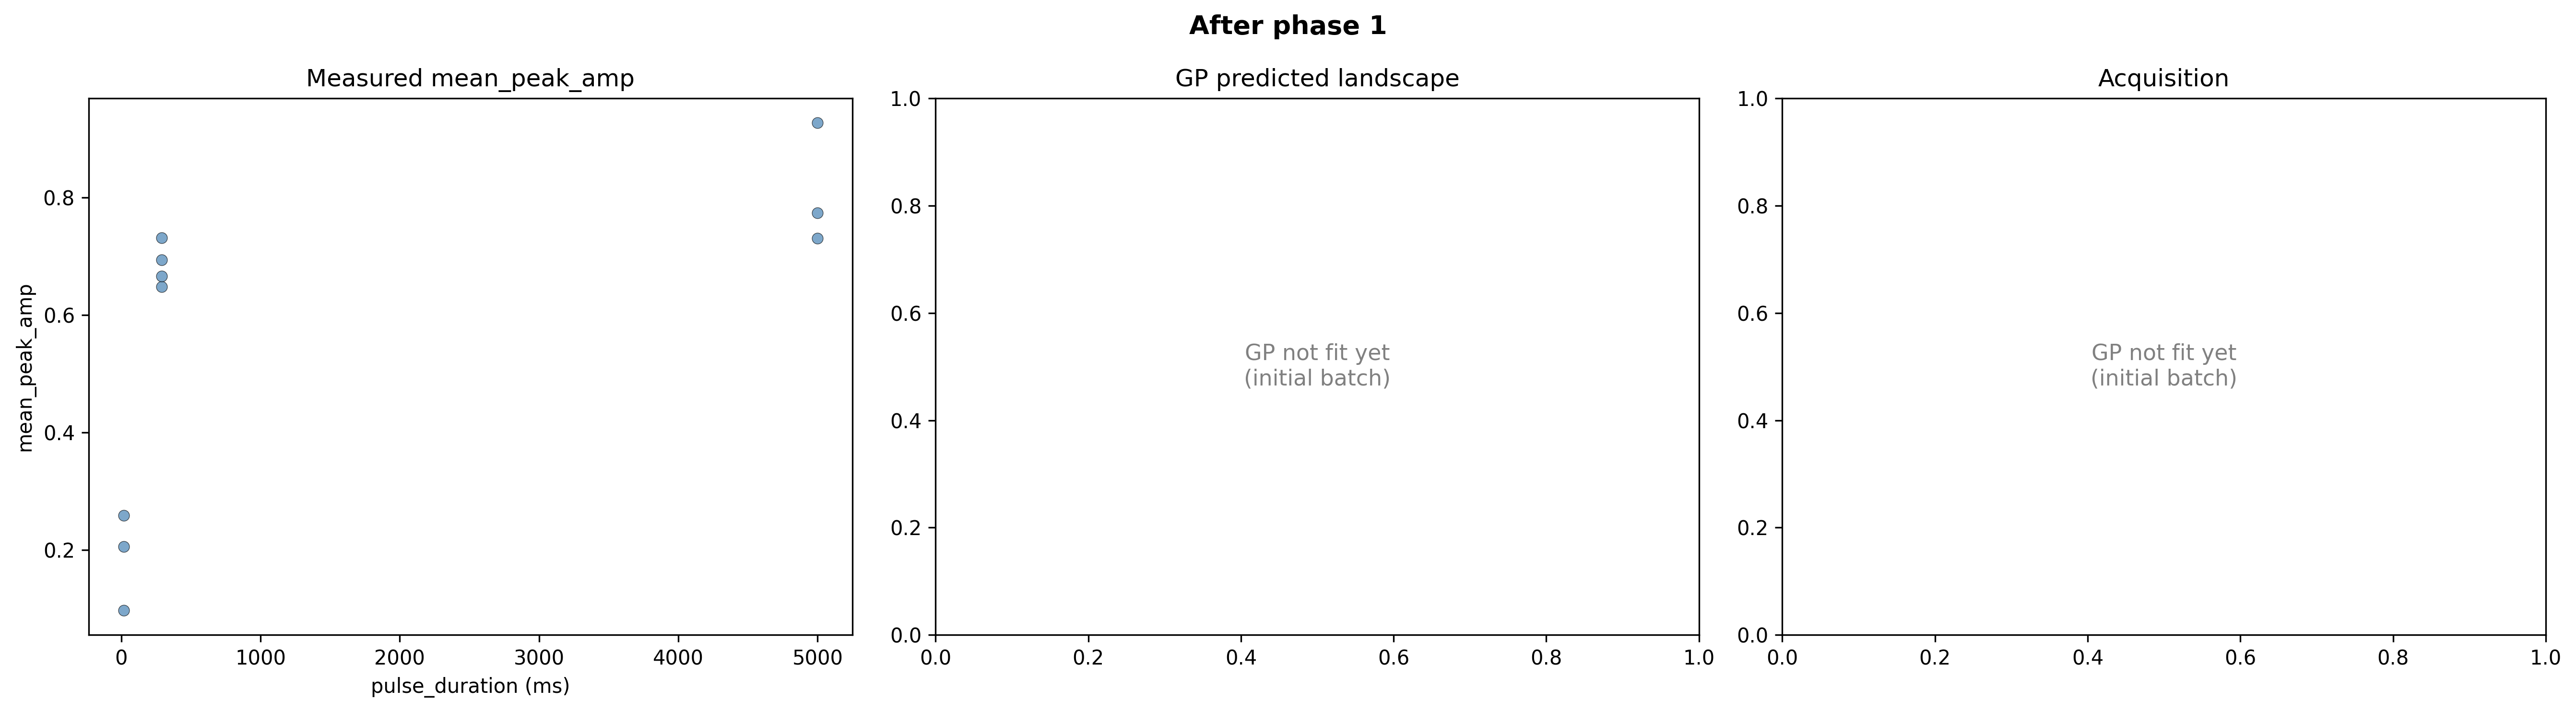


=== ComposedAgent: phase 2/7 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 1 — selected FOVs:
    H8_0000: 49 cells
    H8_0001: 36 cells
    H8_0002: 60 cells
    H9_0000: 165 cells (rejected: above_max_cells)
    H9_0001: 28 cells (rejected: below_min_cells)
    H9_0002: 20 cells (rejected: below_min_cells)
    H10_0000: 44 cells
    H10_0001: 70 cells
    H10_0002: 19 cells (rejected: below_min_cells)
    H11_0000: 33 cells
    H11_0001: 69 cells
    H11_0002: 53 cells
    H12_0000: 66 cells
    H12_0001: 31 cells
    H12_0002: 62 cells
    G12_0000: 52 cells
    G12_0001: 26 cells (rejected: below_min_cells)
    G12_0002: 8 cells (rejected: below_min_cells)
  Fitting task = 'auc' (column = 'mean_peak_amp', logit=False)
    [auc: warmup phase 1/2 -- fitting all 3 candidates]
      hill: obj=0.1544, log_evidence=-4.241
      exponential: obj=0.1728, log_evidence=-4.537
      power_law: obj=0.2027, log_evidence=-4.418
    [auc: warmup winner='hill', obj=0.1544]
  Fitting task = 'frac' (column = 'frac_peak_responders', logit=True)
    [

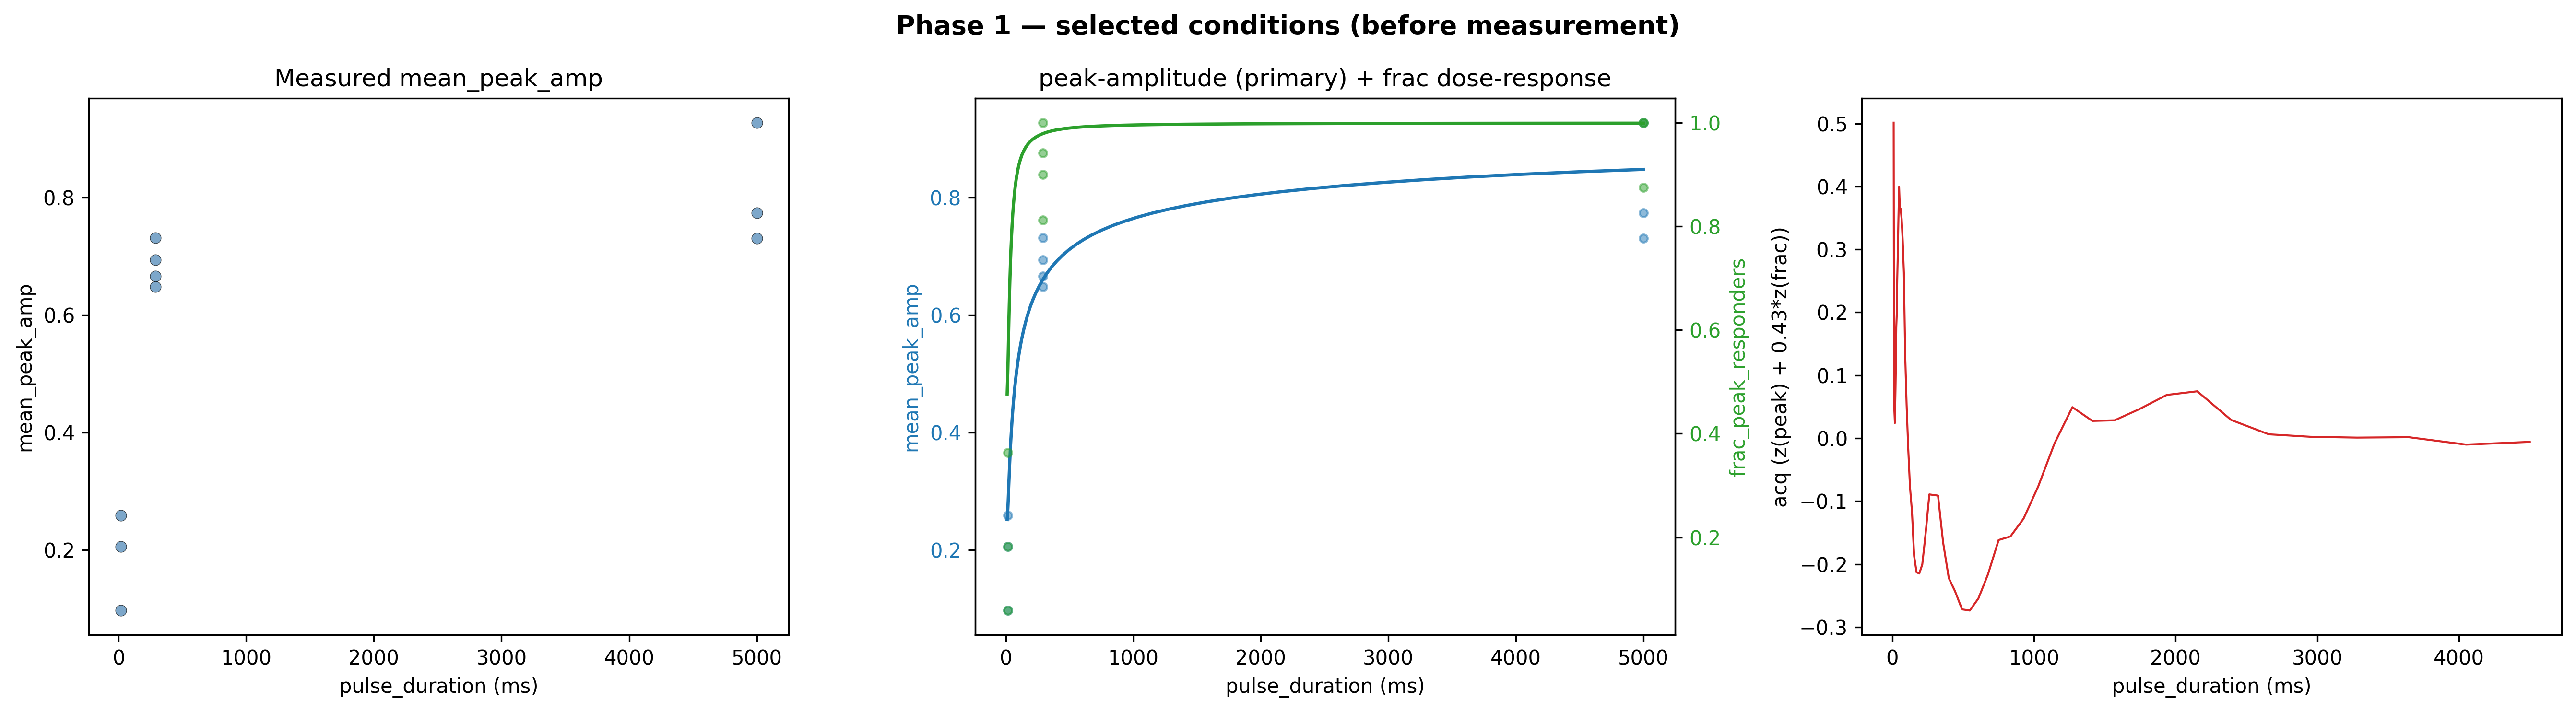

  Created 558 events for phase 1
    Cond 0 (FOVs 18-23): pulse_duration=10ms
    Cond 1 (FOVs 24-29): pulse_duration=54ms
    Cond 2 (FOVs 30-35): pulse_duration=32ms


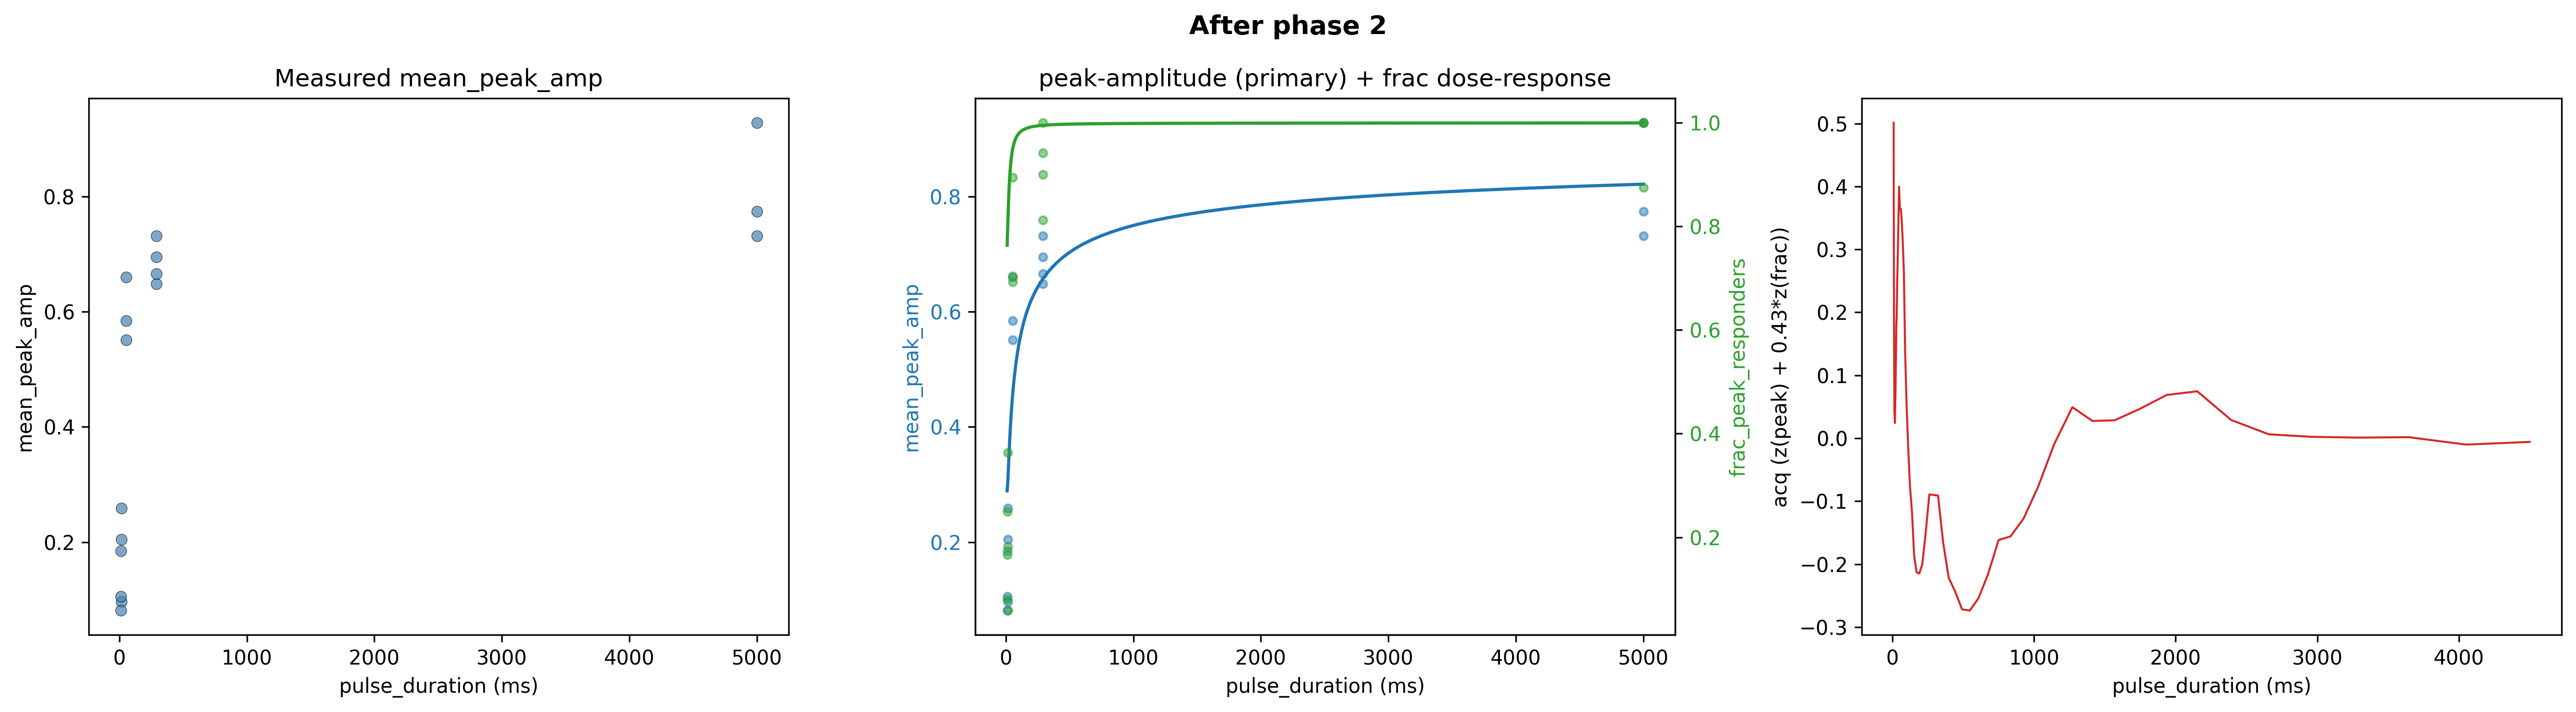

  [v4 convergence] peak-curve RMS change=n/a (tol 0.05), family='hill', frac half-recruitment dose=11 ms, converged=False

=== ComposedAgent: phase 3/7 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 2 — selected FOVs:
    G11_0000: 41 cells
    G11_0001: 31 cells
    G11_0002: 24 cells (rejected: below_min_cells)
    G10_0000: 38 cells
    G10_0001: 26 cells (rejected: below_min_cells)
    G10_0002: 17 cells (rejected: below_min_cells)
    G9_0000: 87 cells
    G9_0001: 57 cells
    G9_0002: 22 cells (rejected: below_min_cells)
    G8_0000: 58 cells
    G8_0001: 9 cells (rejected: below_min_cells)
    G8_0002: 8 cells (rejected: below_min_cells)
    G7_0000: 48 cells
    G7_0001: 13 cells (rejected: below_min_cells)
    G7_0002: 8 cells (rejected: below_min_cells)
    G6_0000: 24 cells (rejected: below_min_cells)
    G6_0001: 9 cells (rejected: below_min_cells)
    G6_0002: 8 cells (rejected: below_min_cells)
  Fitting task = 'auc' (column = 'mean_peak_amp', logit=False)
    [auc: warmup phase 2/2 -- fitting all 3 candidates]
      hill: obj=0.0862, log_evidence=-6.132
      exponential: obj=0.0912, log_evidence=-4.421
      power_law: obj=0.1071, log_eviden

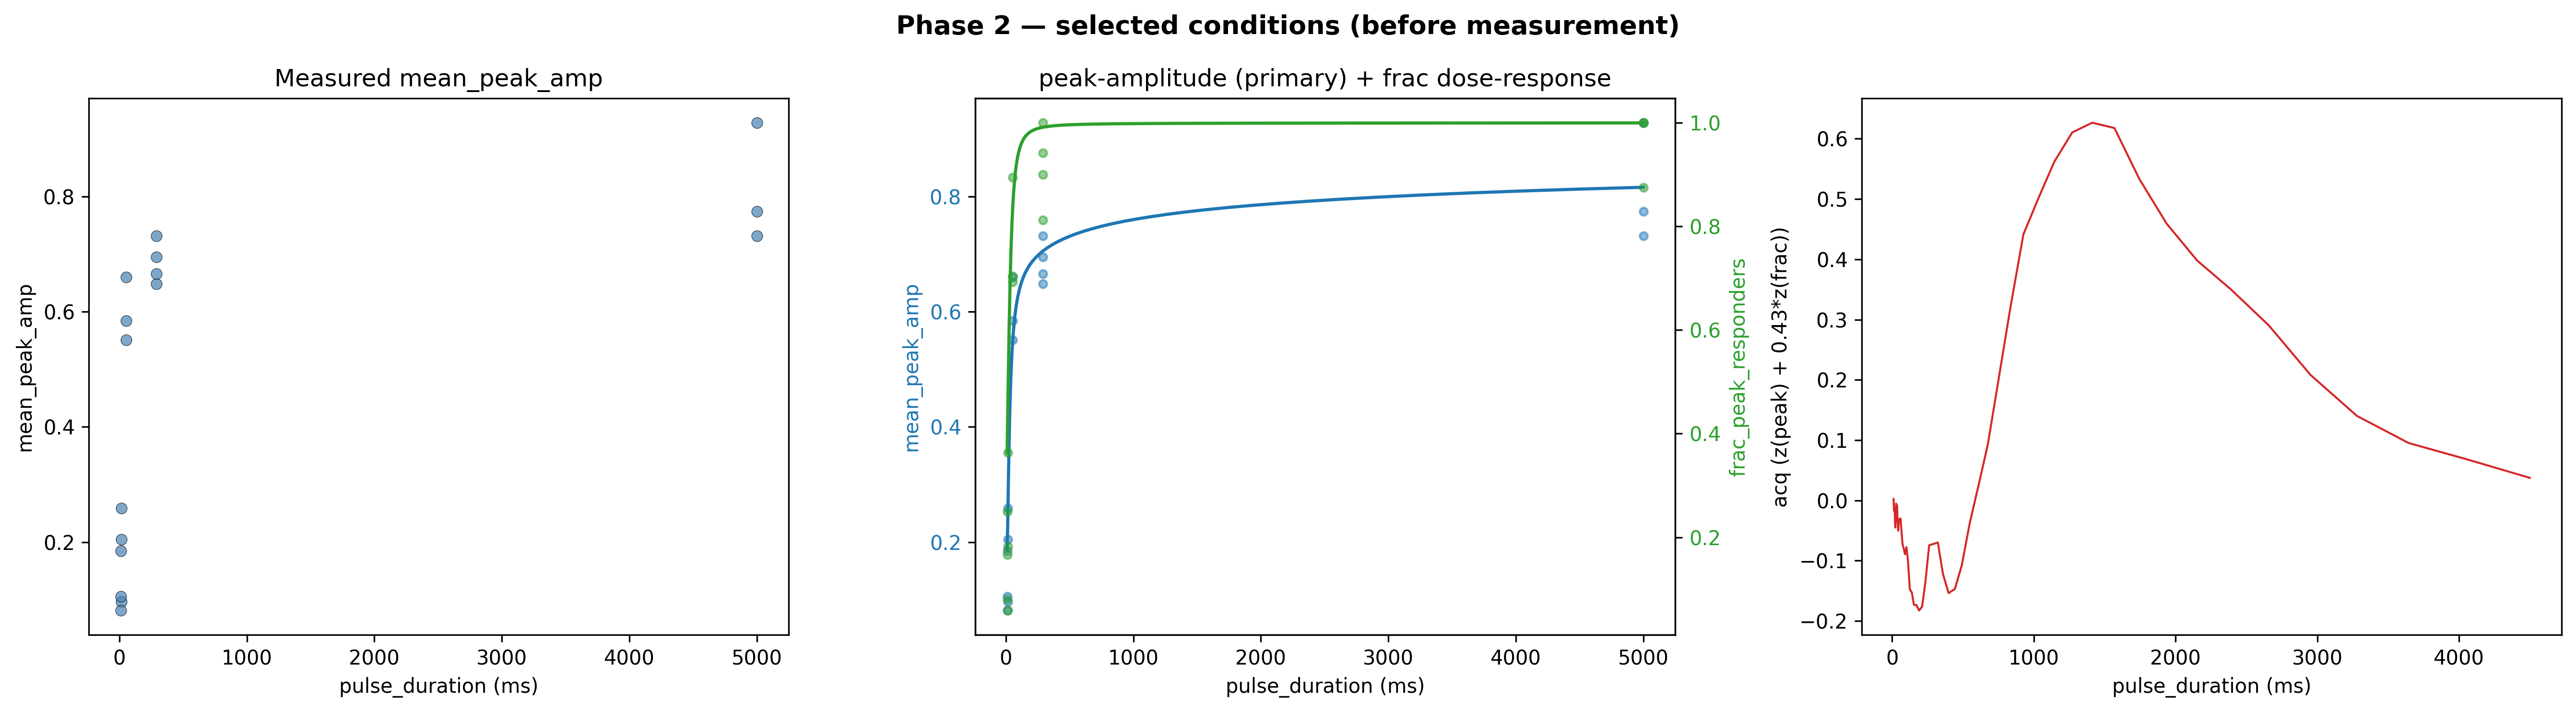

  Created 558 events for phase 2
    Cond 0 (FOVs 36-41): pulse_duration=1413ms
    Cond 1 (FOVs 42-47): pulse_duration=2658ms
    Cond 2 (FOVs 48-53): pulse_duration=834ms


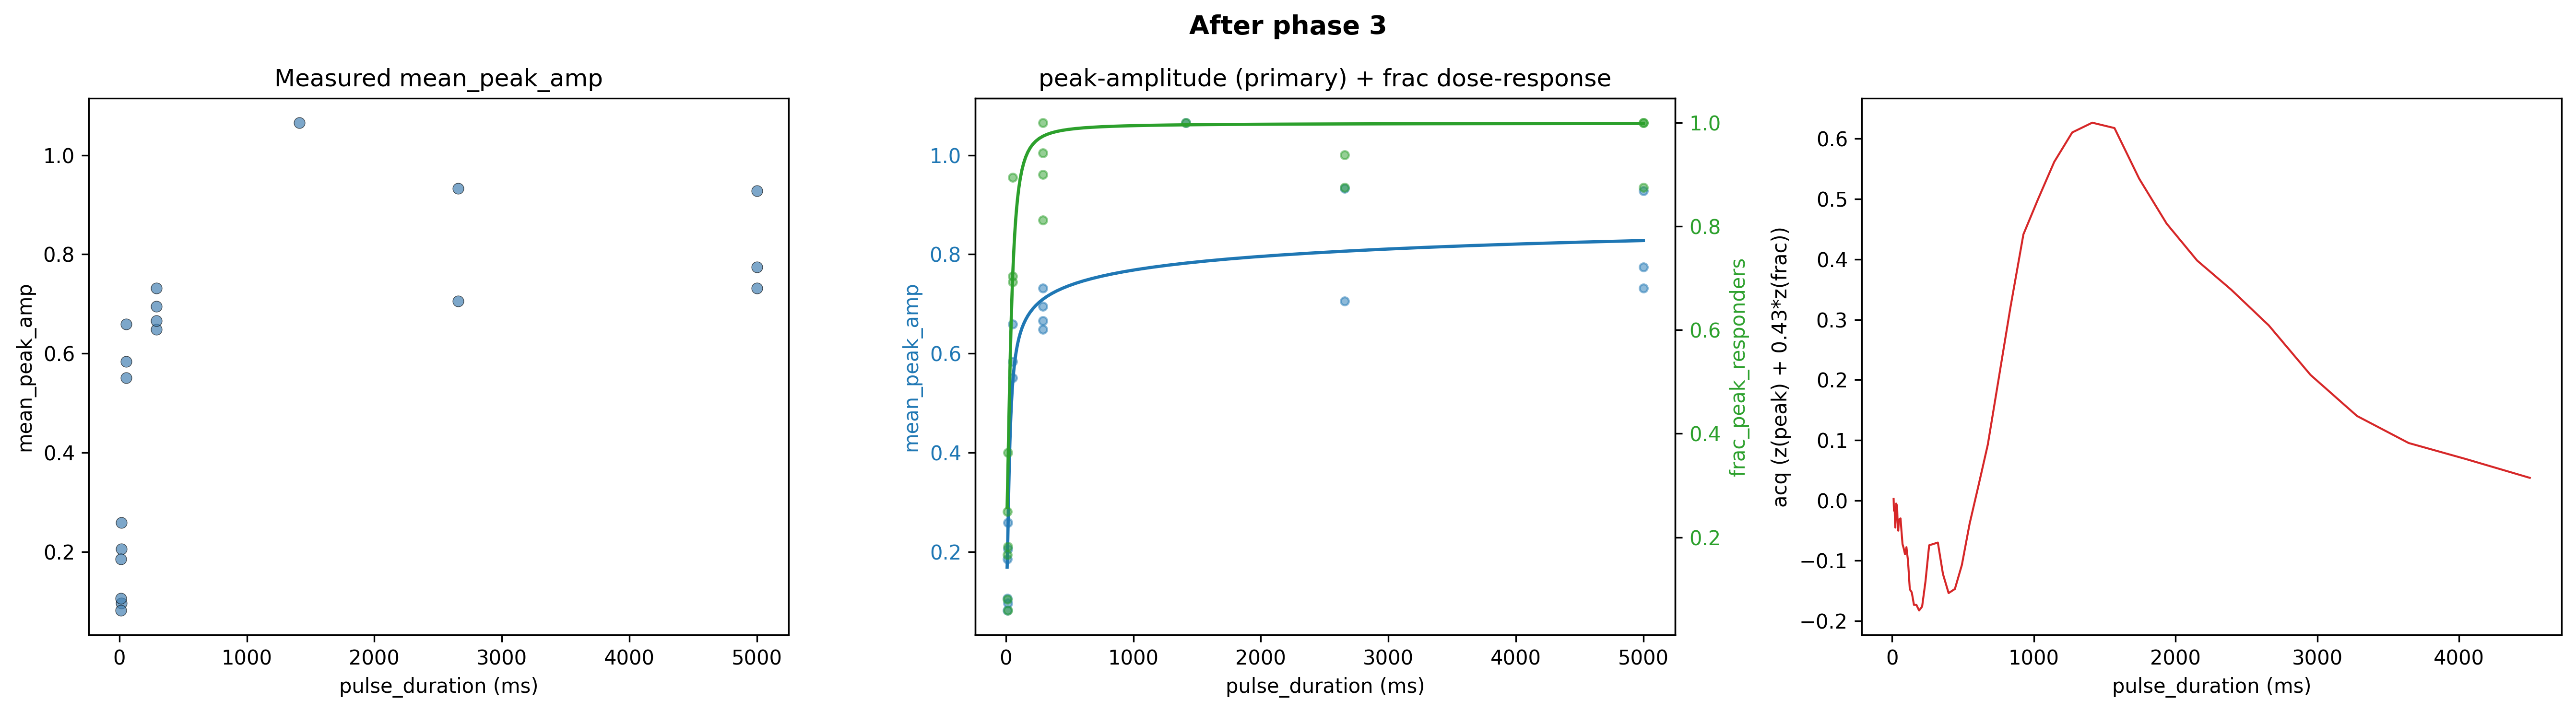

  [v4 convergence] peak-curve RMS change=0.093 (tol 0.05), family='hill', frac half-recruitment dose=26 ms, converged=False

=== ComposedAgent: phase 4/7 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 3 — selected FOVs:
    G5_0000: 30 cells
    G5_0001: 51 cells
    G5_0002: 23 cells (rejected: below_min_cells)
    G4_0000: 38 cells
    G4_0001: 42 cells
    G4_0002: 52 cells
    G3_0000: 32 cells
    G3_0001: 53 cells
    G3_0002: 53 cells
    G2_0000: 49 cells
    G2_0001: 37 cells
    G2_0002: 27 cells (rejected: below_min_cells)
    F2_0000: 37 cells
    F2_0001: 37 cells
    F2_0002: 27 cells (rejected: below_min_cells)
    F3_0000: 40 cells
    F3_0001: 67 cells
    F3_0002: 43 cells
  Fitting task = 'auc' (column = 'mean_peak_amp', logit=False)
    [auc: eps-greedy -> 'hill'  (hill=+1.00(n=2), exponential=+0.00(n=2), power_law=+0.00(n=2))]
    [auc: obj=0.0776 (prev_finite=0.0862) -> reward=+1]
  Fitting task = 'frac' (column = 'frac_peak_responders', logit=True)
    [frac: eps-greedy -> 'hill'  (hill=+1.00(n=2), exponential=+0.00(n=2))]
    [frac: obj=0.1904 (prev_finite=0.1691) -> reward=-1]
  AUC-primary acq stats (frac_w=0.43): min=-0.1317, max=0.2

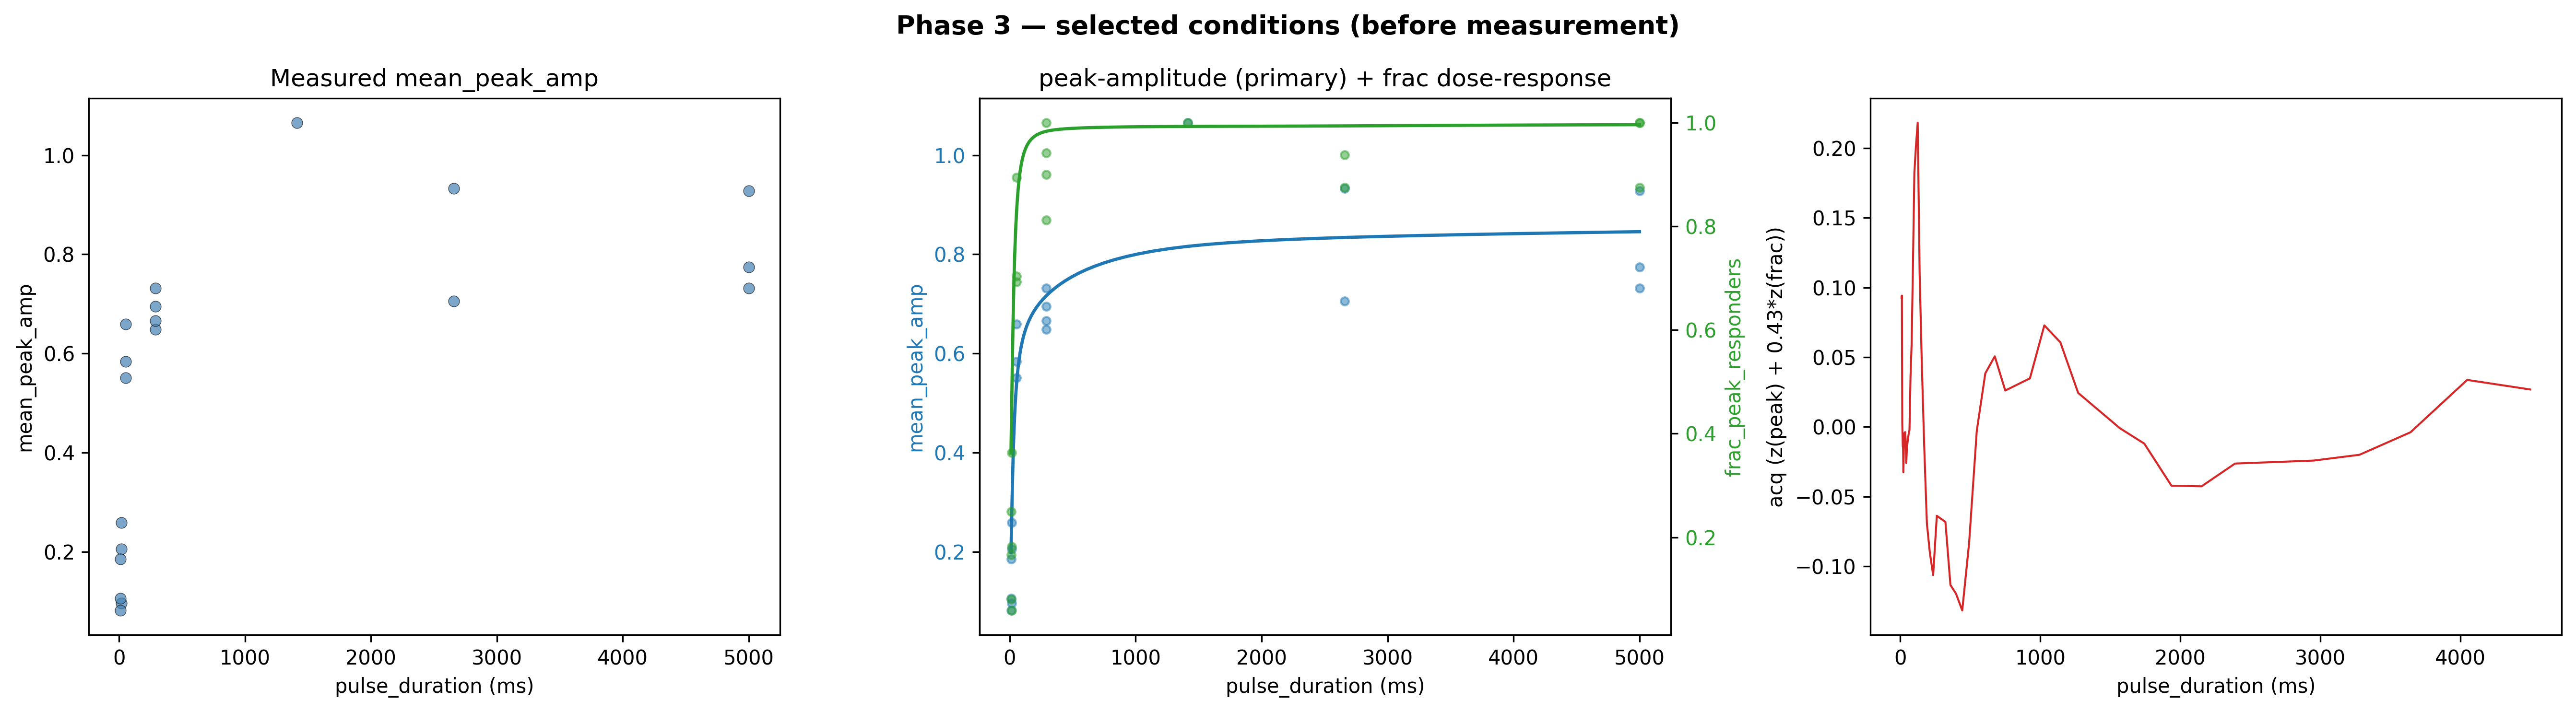

  Created 558 events for phase 3
    Cond 0 (FOVs 54-59): pulse_duration=125ms
    Cond 1 (FOVs 60-65): pulse_duration=12ms
    Cond 2 (FOVs 66-71): pulse_duration=82ms
  optoRTK retry summary: 1/1 recovered after re-read


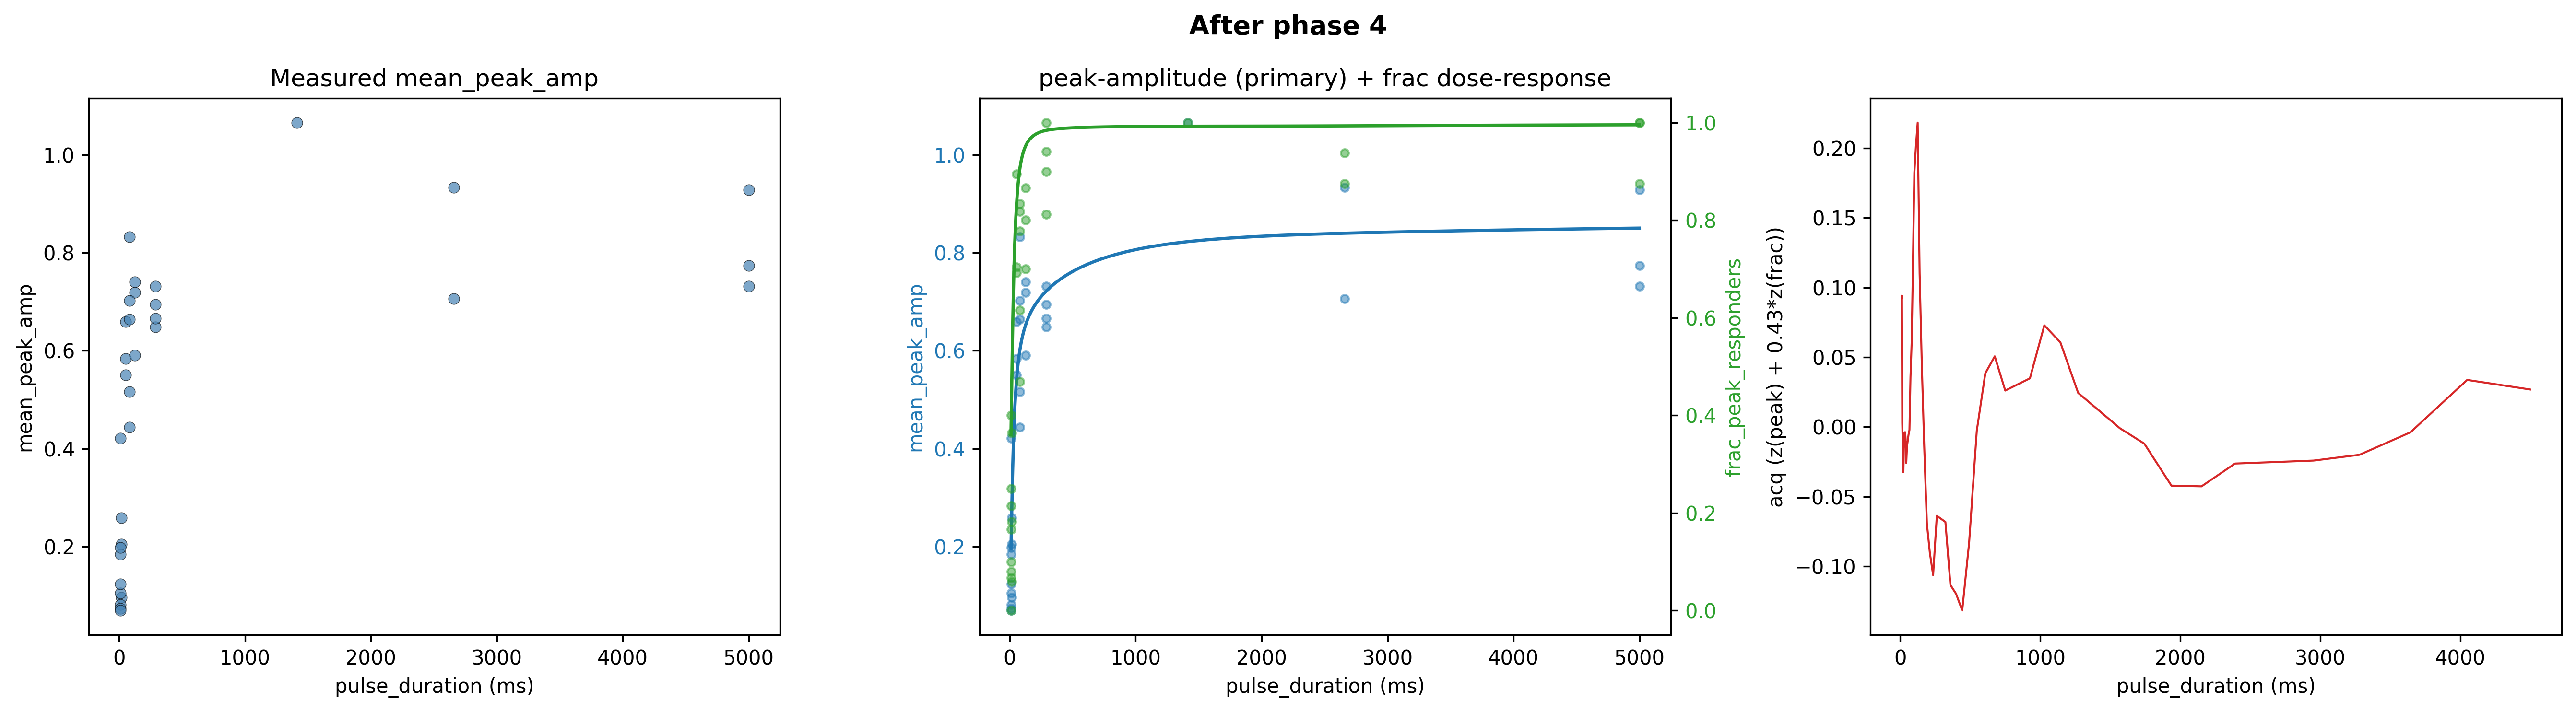

  [v4 convergence] peak-curve RMS change=0.053 (tol 0.05), family='hill', frac half-recruitment dose=26 ms, converged=False

=== ComposedAgent: phase 5/7 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 4 — selected FOVs:
    F4_0000: 37 cells
    F4_0001: 34 cells
    F4_0002: 57 cells
    F5_0000: 55 cells
    F5_0001: 44 cells
    F5_0002: 39 cells
    F6_0000: 50 cells
    F6_0001: 72 cells
    F6_0002: 105 cells (rejected: above_max_cells)
    F7_0000: 61 cells
    F7_0001: 36 cells
    F7_0002: 33 cells
    F8_0000: 82 cells
    F8_0001: 25 cells (rejected: below_min_cells)
    F8_0002: 23 cells (rejected: below_min_cells)
    F9_0000: 22 cells (rejected: below_min_cells)
    F9_0001: 16 cells (rejected: below_min_cells)
    F9_0002: 16 cells (rejected: below_min_cells)
  Fitting task = 'auc' (column = 'mean_peak_amp', logit=False)
    [auc: eps-greedy -> 'hill'  (hill=+1.00(n=3), exponential=+0.00(n=2), power_law=+0.00(n=2))]
    [auc: obj=0.0470 (prev_finite=0.0776) -> reward=+1]
  Fitting task = 'frac' (column = 'frac_peak_responders', logit=True)
    [frac: eps-greedy -> 'hill'  (hill=+0.33(n=3), exponential=+0.00(n=2))]
    [frac: obj=0.1111 (prev_fin

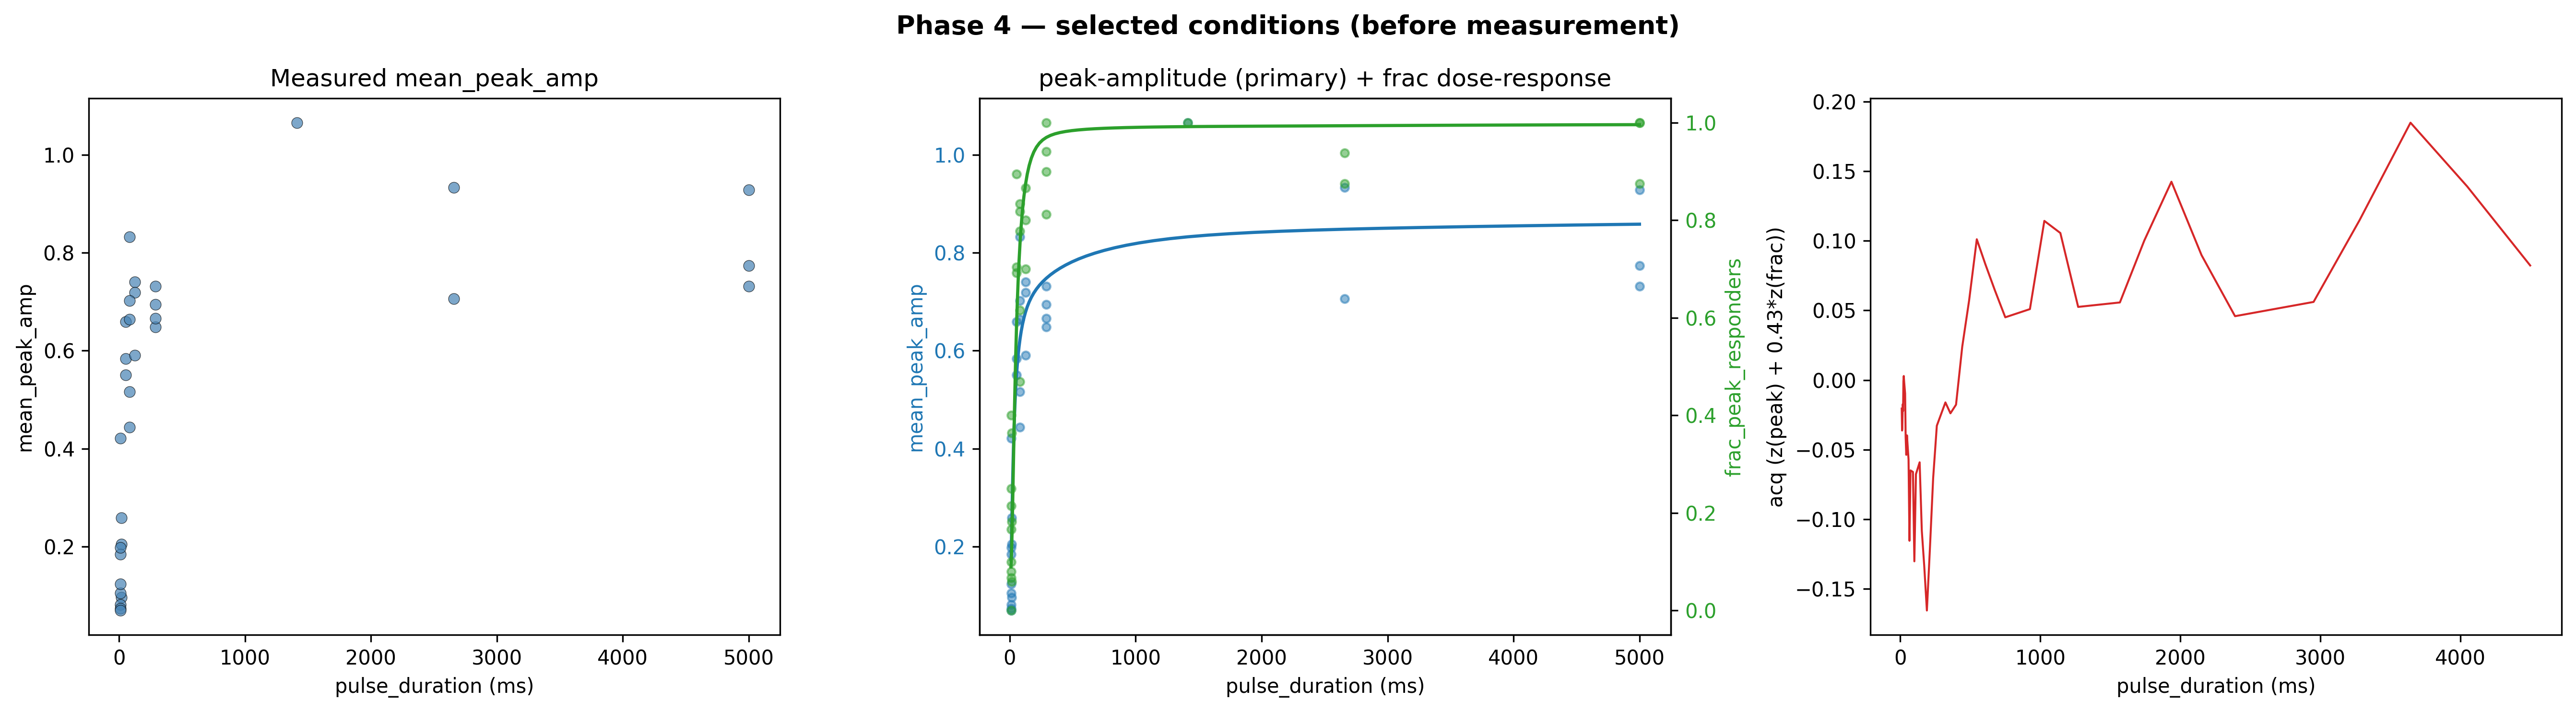

  Created 558 events for phase 4
    Cond 0 (FOVs 72-77): pulse_duration=3645ms
    Cond 1 (FOVs 78-83): pulse_duration=1938ms
    Cond 2 (FOVs 84-89): pulse_duration=1144ms


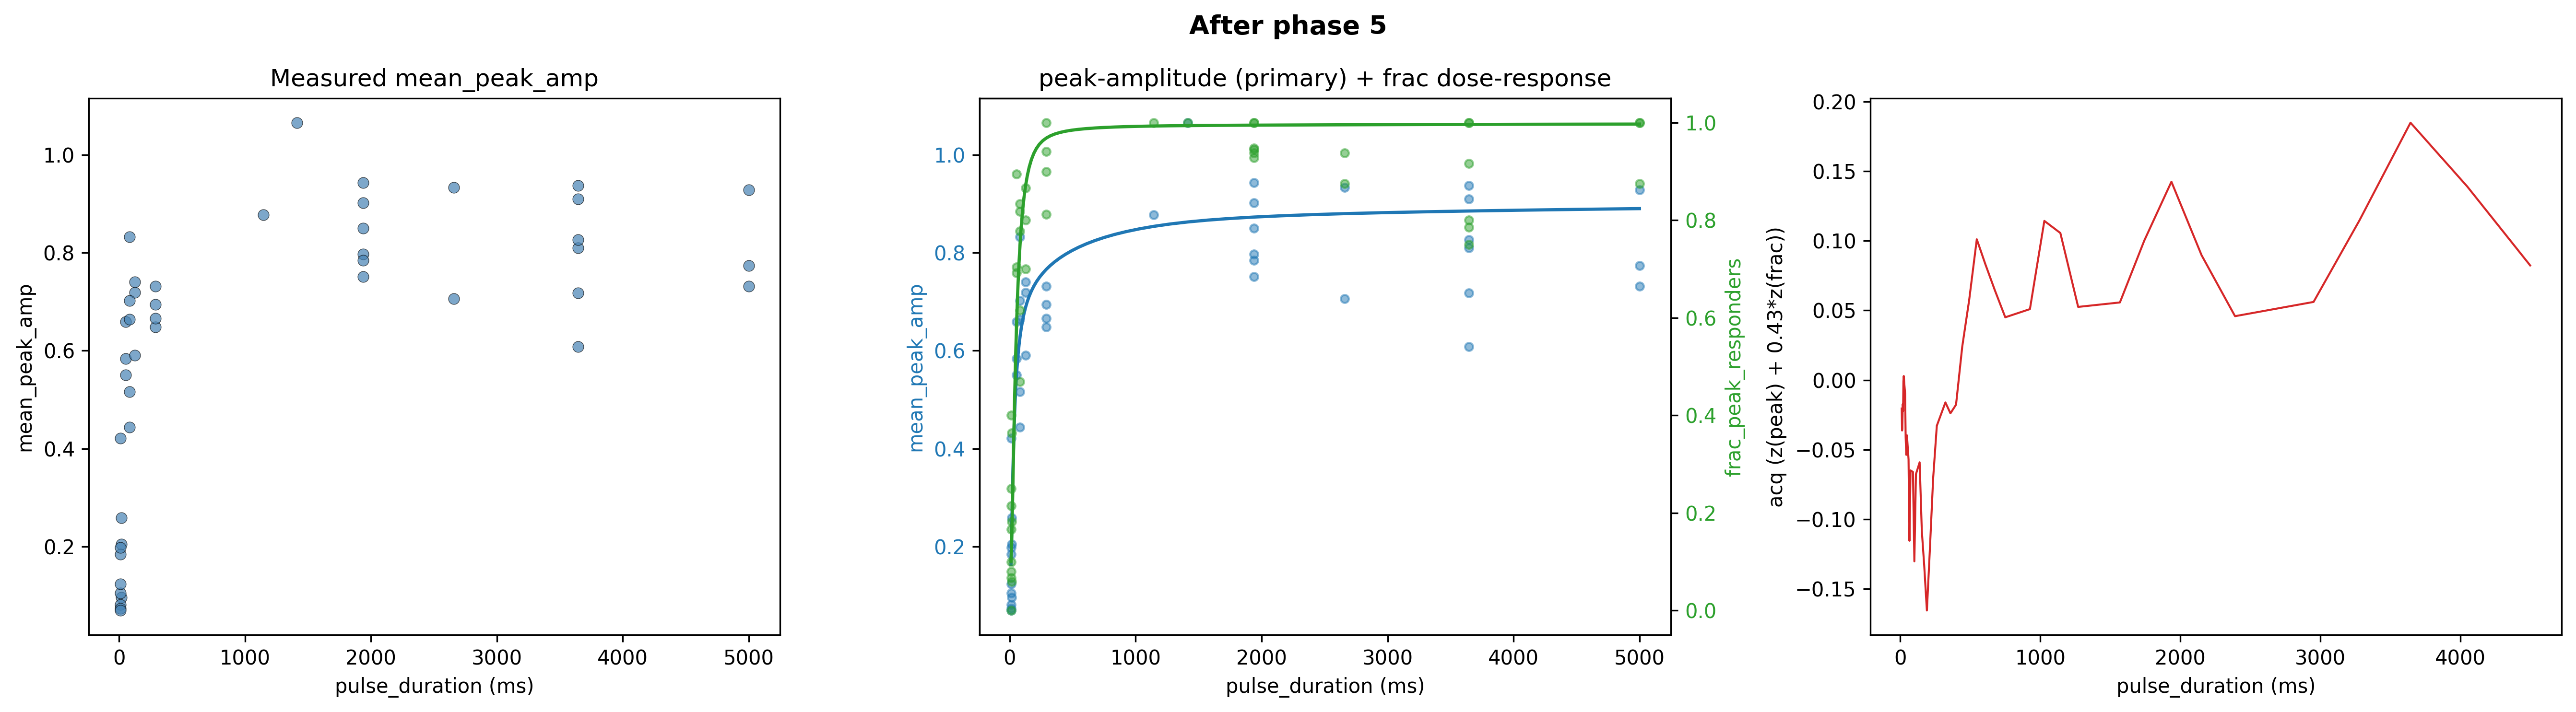

  [v4 convergence] peak-curve RMS change=0.039 (tol 0.05), family='hill', frac half-recruitment dose=44 ms, converged=False

=== ComposedAgent: phase 6/7 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(
no seeds found in get_masks_torch - no masks found.


[FOVFinderAgent] Phase 5 — selected FOVs:
    F10_0000: 40 cells
    F10_0001: 38 cells
    F10_0002: 32 cells
    F11_0000: 38 cells
    F11_0001: 22 cells (rejected: below_min_cells)
    F11_0002: 21 cells (rejected: below_min_cells)
    F12_0000: 80 cells
    F12_0001: 29 cells (rejected: below_min_cells)
    F12_0002: 26 cells (rejected: below_min_cells)
    E12_0000: 77 cells
    E12_0001: 17 cells (rejected: below_min_cells)
    E12_0002: 13 cells (rejected: below_min_cells)
    E11_0000: 58 cells
    E11_0001: 18 cells (rejected: below_min_cells)
    E11_0002: 16 cells (rejected: below_min_cells)
    E10_0000: 38 cells
    E10_0001: 49 cells
    E10_0002: 42 cells
  Fitting task = 'auc' (column = 'mean_peak_amp', logit=False)
    [auc: eps-greedy -> 'exponential'  (hill=+1.00(n=4), exponential=+0.00(n=2), power_law=+0.00(n=2))]
    [auc: obj=0.0386 (prev_finite=0.0470) -> reward=+1]
  Fitting task = 'frac' (column = 'frac_peak_responders', logit=True)
    [frac: eps-greedy -> 'e

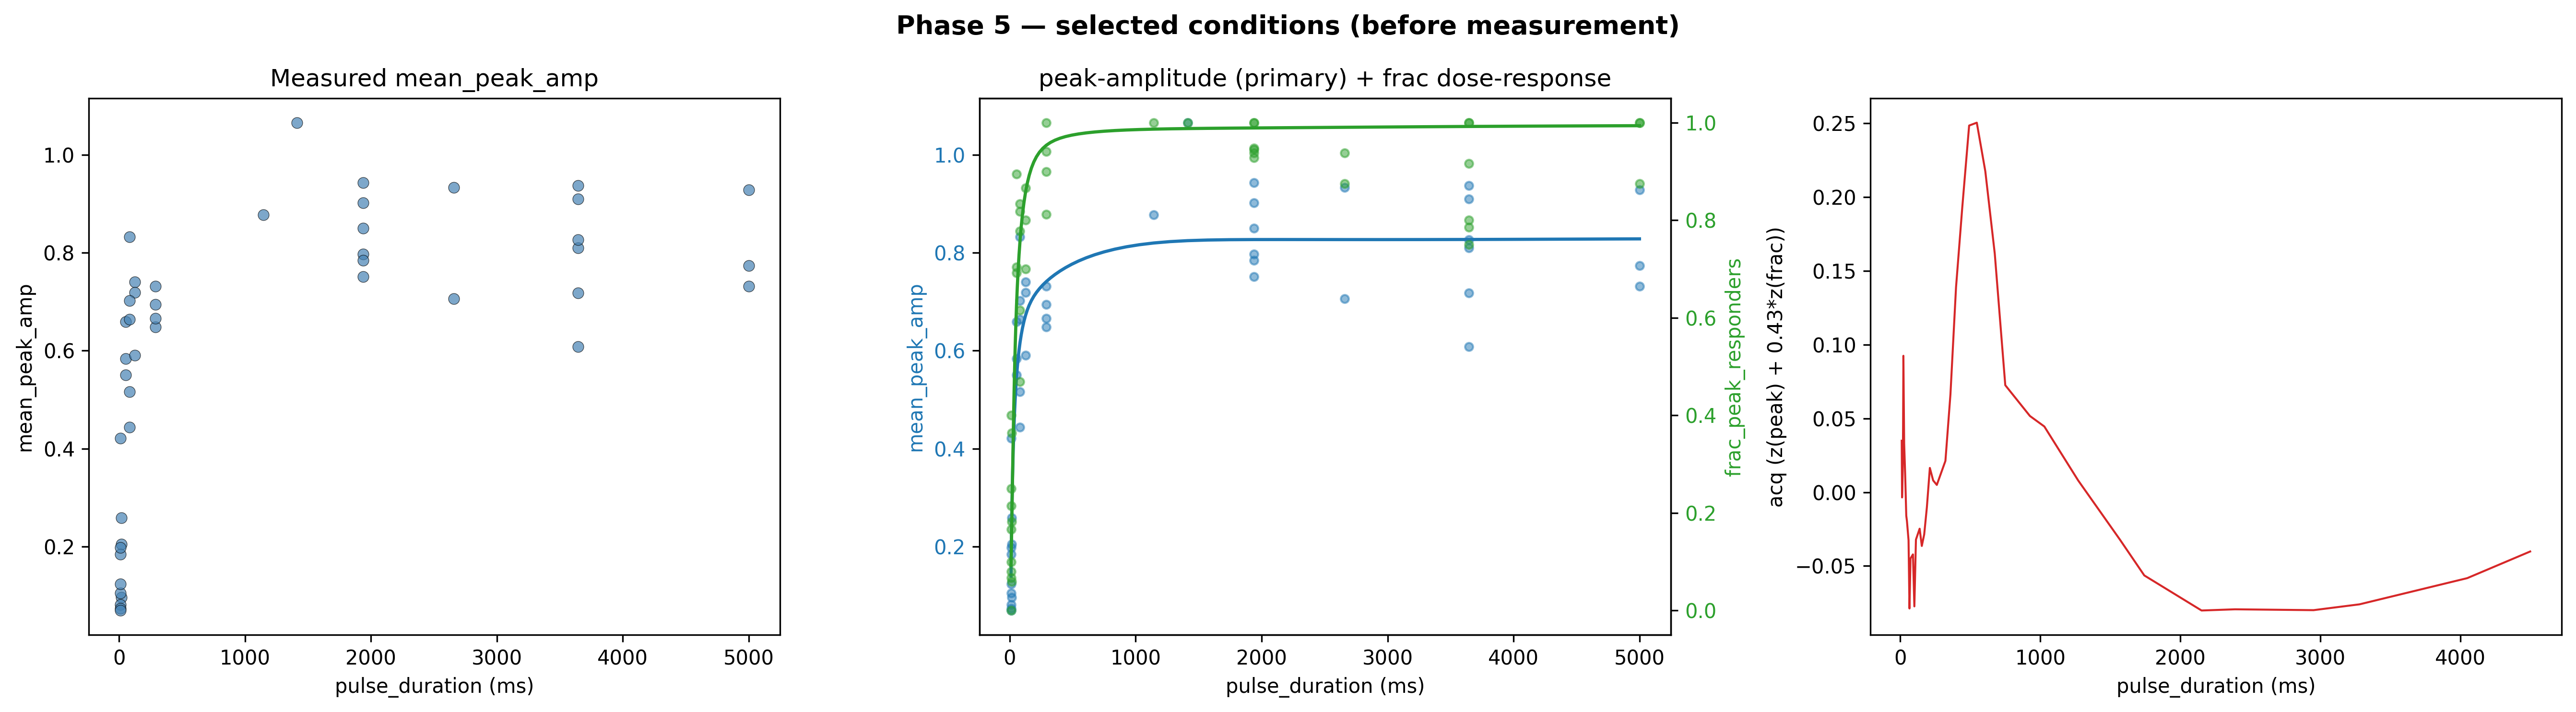

  Created 558 events for phase 5
    Cond 0 (FOVs 90-95): pulse_duration=547ms
    Cond 1 (FOVs 96-101): pulse_duration=676ms
    Cond 2 (FOVs 102-107): pulse_duration=399ms


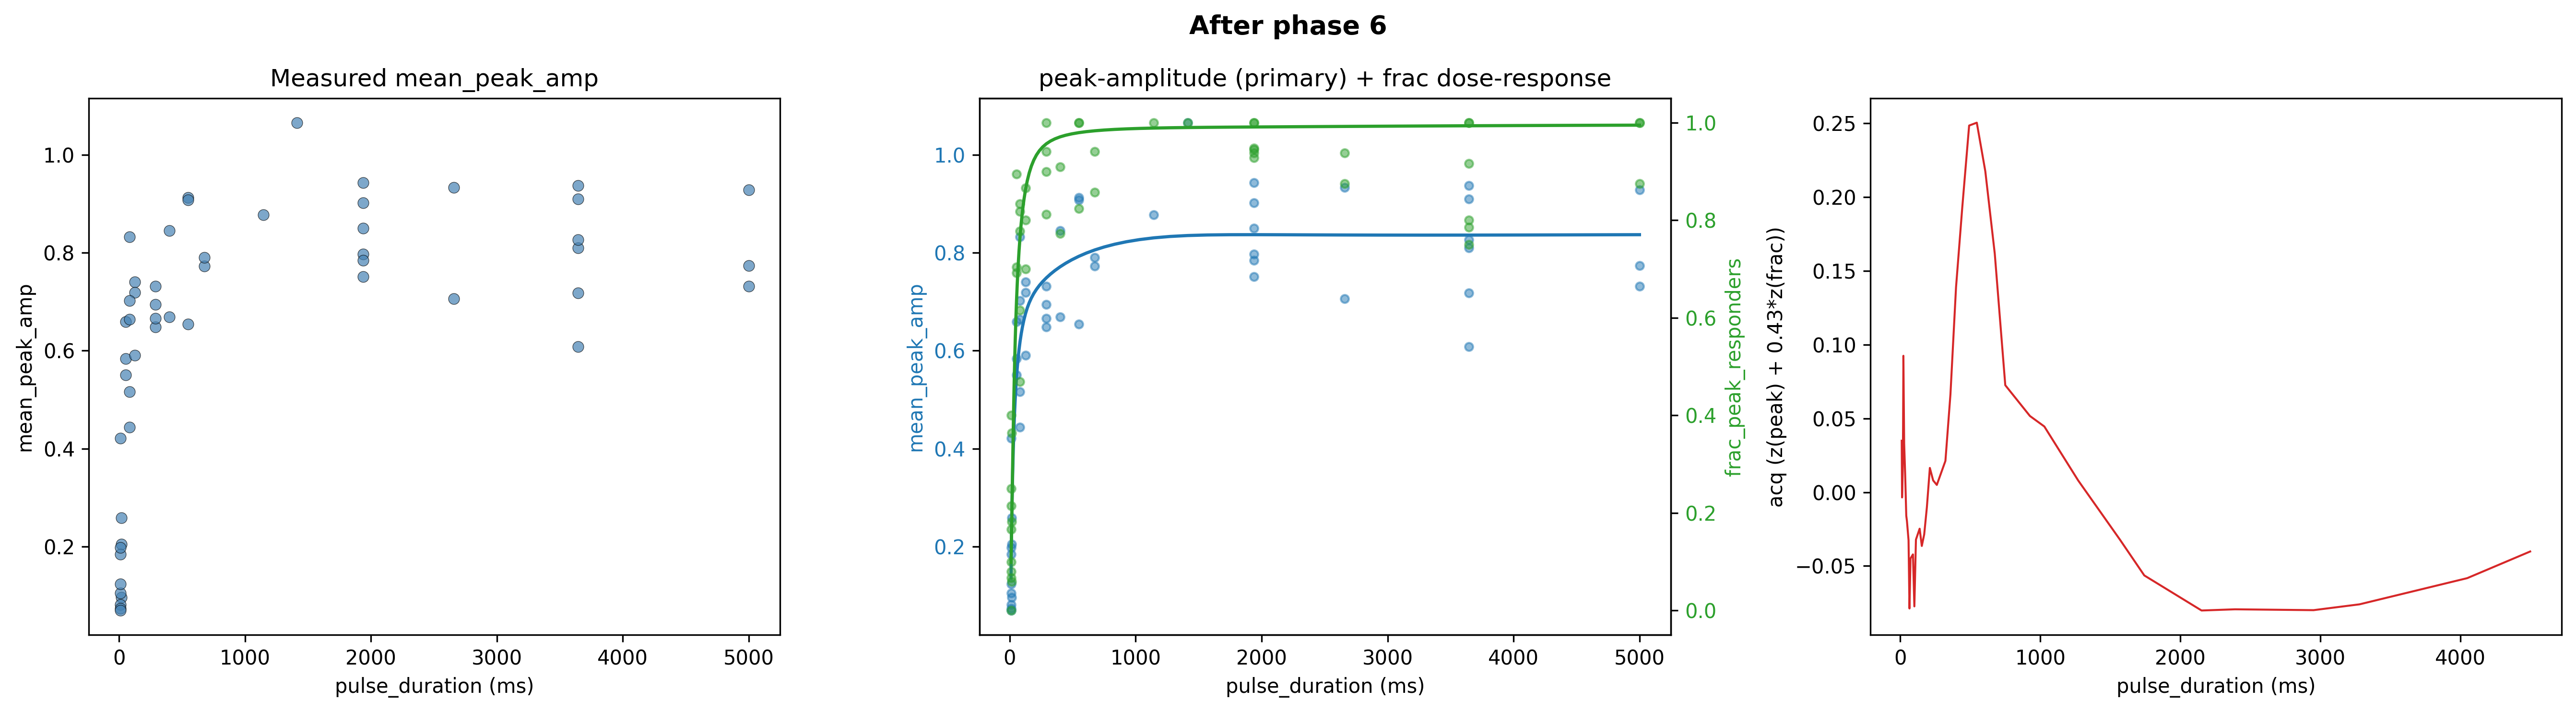

  [v4 convergence] peak-curve RMS change=0.036 (tol 0.05), family='hill', frac half-recruitment dose=39 ms, converged=True

=== ComposedAgent: phase 7/7 ===


C:\Users\Jungfrau\Documents\alandolt\code\faro.worktrees\feat-agent_mode\faro\segmentation\cellpose_v4.py:55: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  masks = skimage.morphology.remove_small_objects(


[FOVFinderAgent] Phase 6 — selected FOVs:
    E9_0000: 40 cells
    E9_0001: 9 cells (rejected: below_min_cells)
    E9_0002: 7 cells (rejected: below_min_cells)
    E8_0000: 32 cells
    E8_0001: 21 cells (rejected: below_min_cells)
    E8_0002: 8 cells (rejected: below_min_cells)
    E7_0000: 38 cells
    E7_0001: 40 cells
    E7_0002: 51 cells
    E6_0000: 24 cells (rejected: below_min_cells)
    E6_0001: 6 cells (rejected: below_min_cells)
    E6_0002: 4 cells (rejected: below_min_cells)
    E5_0000: 28 cells (rejected: below_min_cells)
    E5_0001: 23 cells (rejected: below_min_cells)
    E5_0002: 20 cells (rejected: below_min_cells)
    E4_0000: 41 cells
    E4_0001: 23 cells (rejected: below_min_cells)
    E4_0002: 14 cells (rejected: below_min_cells)
  Fitting task = 'auc' (column = 'mean_peak_amp', logit=False)
    [auc: eps-greedy -> 'hill'  (hill=+1.00(n=4), exponential=+0.33(n=3), power_law=+0.00(n=2))]
    [auc: obj=0.0320 (prev_finite=0.0386) -> reward=+1]
  Fitting task 

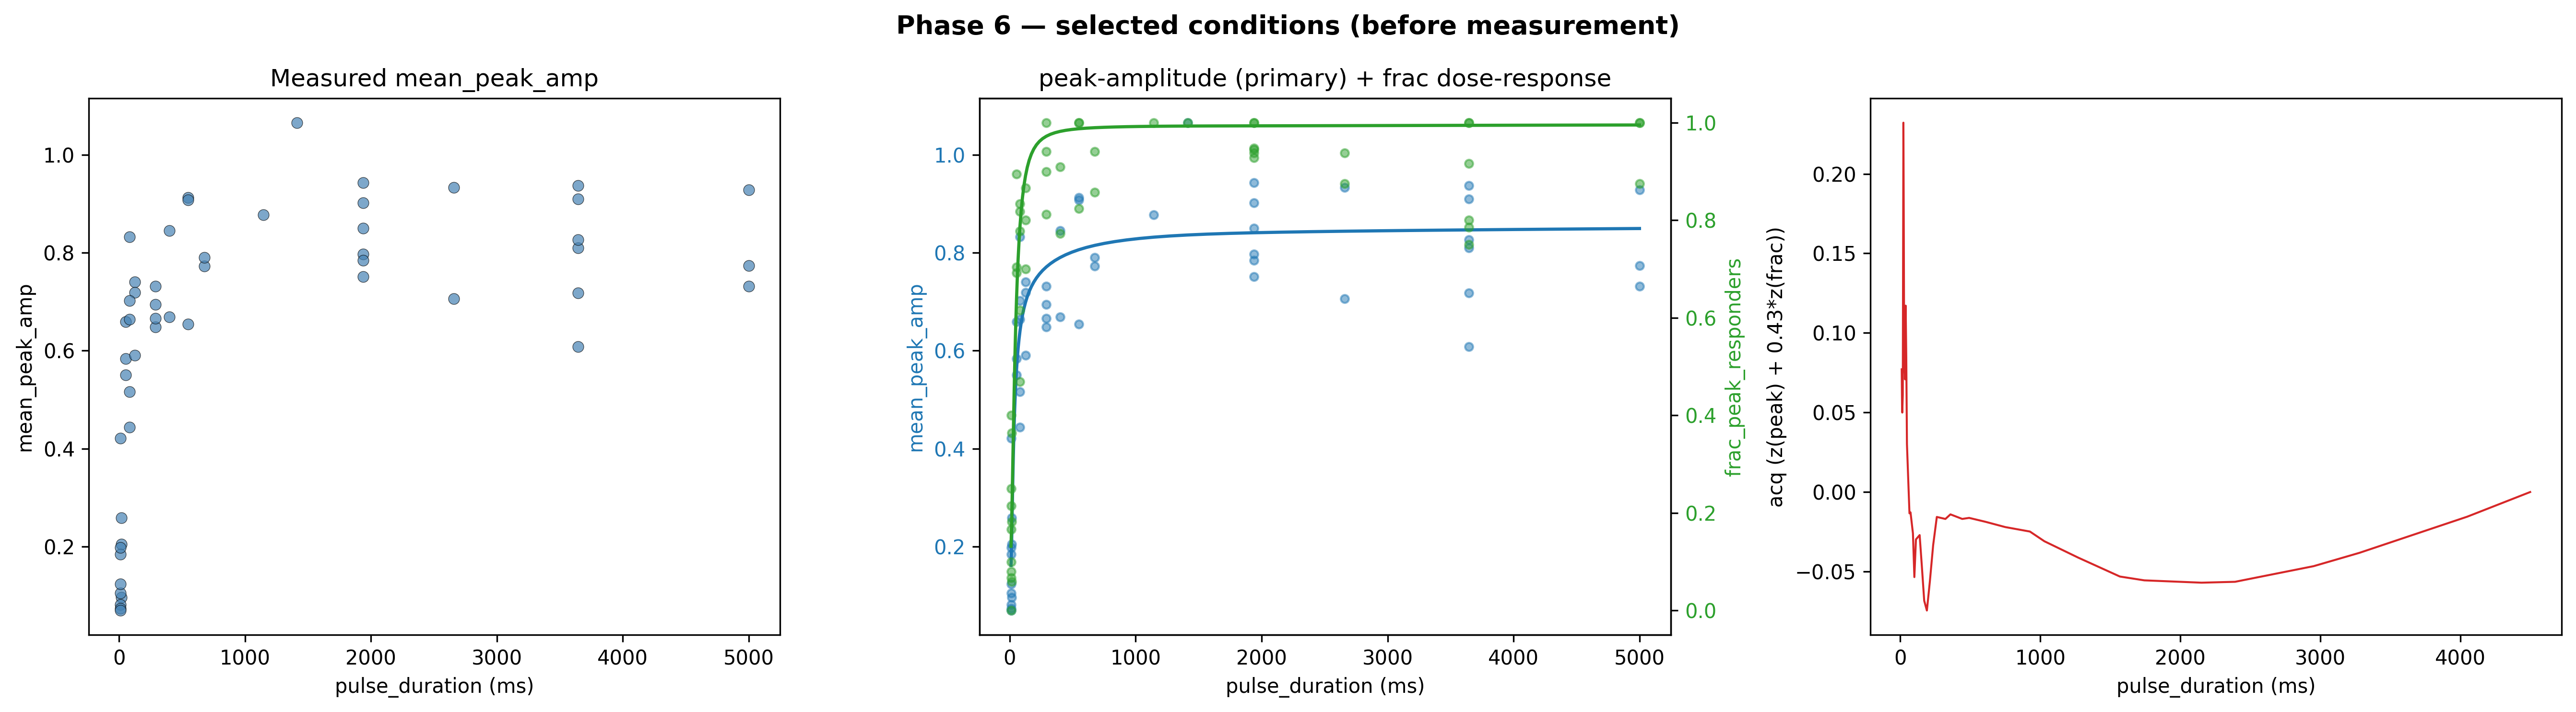

  Created 558 events for phase 6
    Cond 0 (FOVs 108-113): pulse_duration=23ms
    Cond 1 (FOVs 114-119): pulse_duration=39ms
    Cond 2 (FOVs 120-125): pulse_duration=29ms


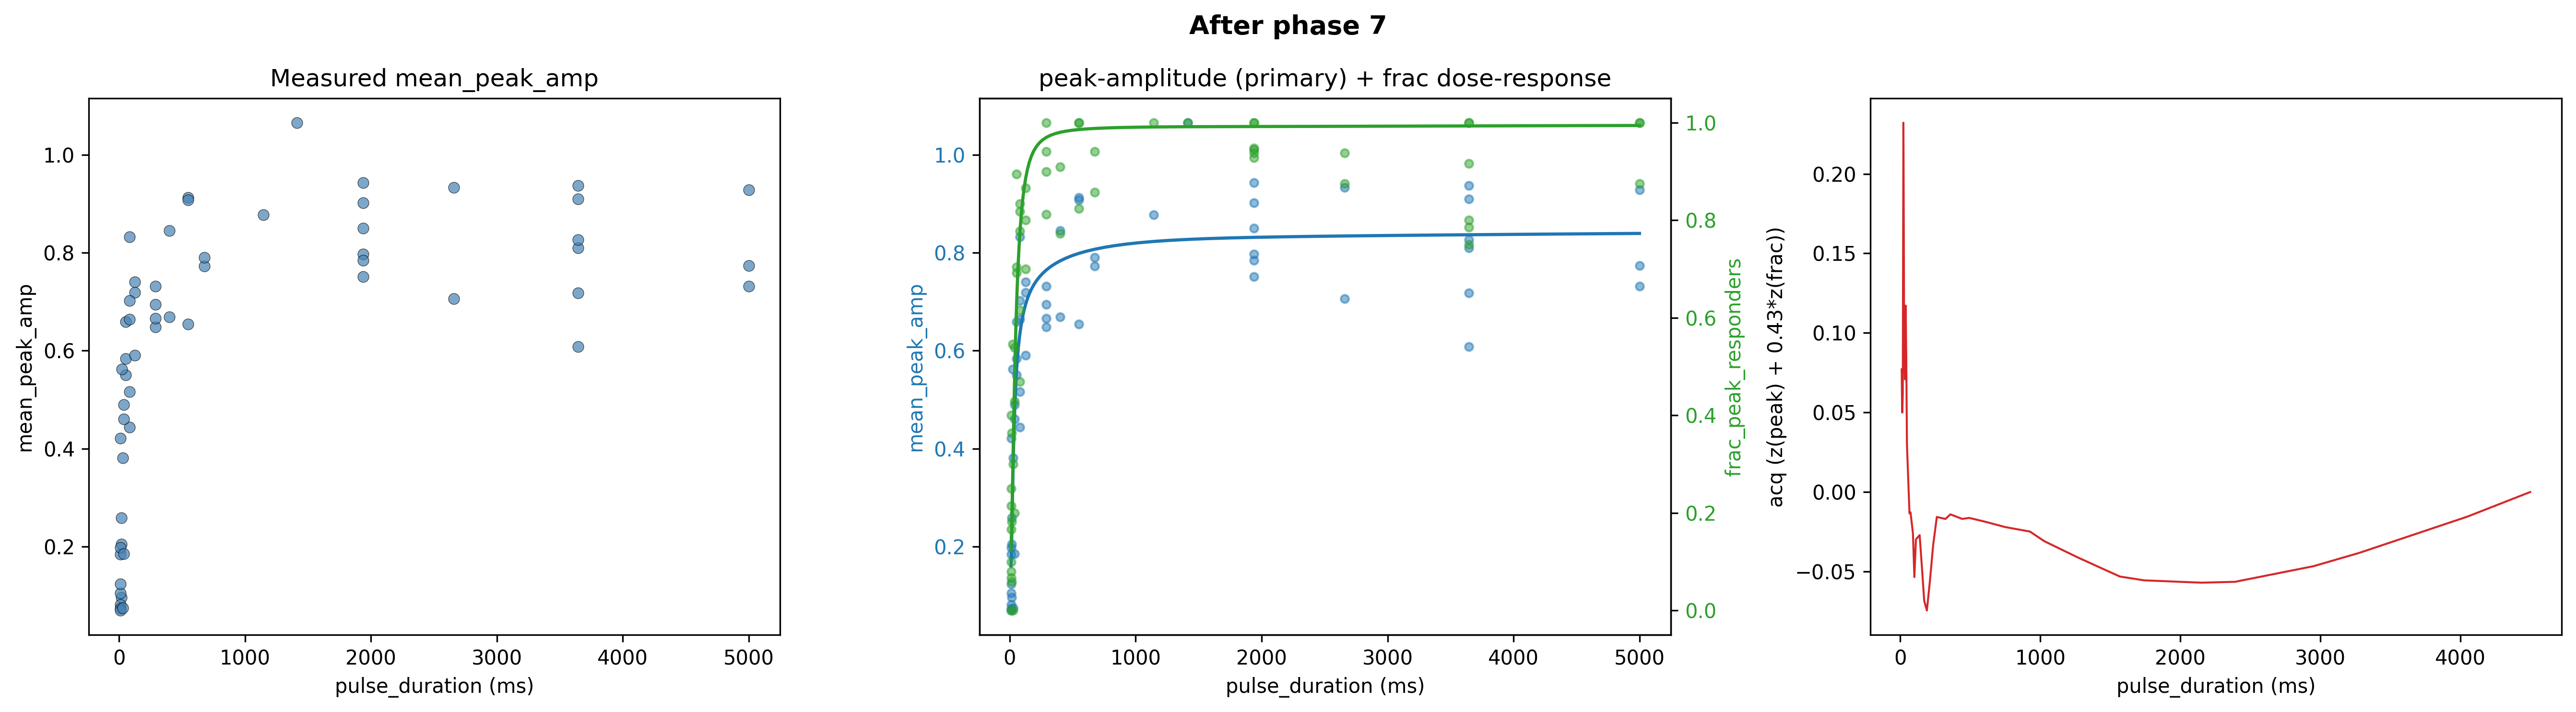

  [v4 convergence] peak-curve RMS change=0.020 (tol 0.05), family='hill', frac half-recruitment dose=44 ms, converged=True
Block 10 done: 58 FOVs, converged-indicator=True


In [13]:
for _ in range(3600 * 12):
    time.sleep(1)  # keep napari responsive and let user abort with Ctrl-C if needed

agents = {}
for _power in POWER_LEVELS:
    agents[_power] = run_power_block(_power)
    print(
        f"Block {_power} done: {len(agents[_power].df_results)} FOVs, "
        f"converged-indicator={agents[_power].is_converged}"
    )

## Analysis 1 -- which model family won the peak task, per power block

The headline scientific output: for each power, did the peak dose-response
select **hill** (cooperative-saturating, has an EC50), **exponential**
(hyperbolic-saturating), or **power_law** (non-saturating)? The selected family
*is* the answer to "does peak ERK amplitude saturate with duration at this
power?".

In [14]:
rows = []
for power, agent in agents.items():
    if agent.df_results is None or agent.df_results.empty:
        continue
    st = agent._task_state["auc"]  # key "auc" carries the peak task in v4
    fam = st.get("selected_hypothesis")
    record = st["record"]
    cands = list(agent.candidate_hypotheses_by_task["auc"])
    rewards = {cands[i]: float(record[i, 1]) for i in range(len(cands))}
    rows.append(
        dict(
            power=power,
            selected_peak_family=fam,
            n_fovs=len(agent.df_results),
            **rewards,
        )
    )
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

 power selected_peak_family  n_fovs  hill  exponential  power_law
    10                 hill      58   1.0     0.333333        0.0


## Analysis 2 -- per-power peak dose-response, stratified by optoRTK expression

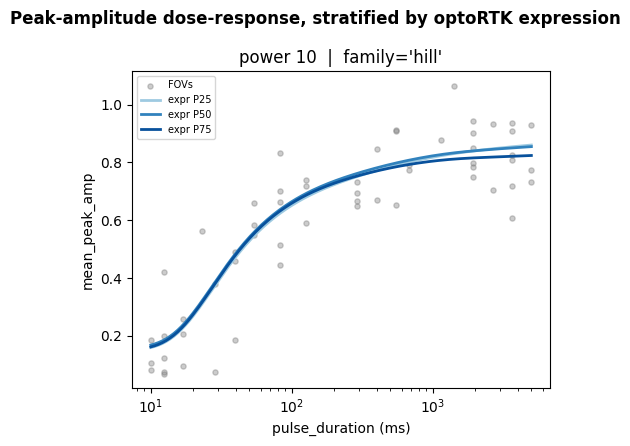

In [15]:
import gpax.utils


def predict_peak_stratified(agent, expr_percentiles=(25, 50, 75), n_dose=200):
    """Peak-amplitude GP curve over the dose grid at low/med/high optoRTK
    expression (baseline_cnr fixed at its median). Returns (doses, {pct: curve})."""
    if "auc" not in agent._gp_models_by_task or agent.df_results is None:
        return None, None
    df = agent.df_results
    gp = agent._gp_models_by_task["auc"]
    y_scaler = agent._y_scalers_by_task["auc"]
    cov_names = [c.name for c in agent.bo_covariates]
    j_expr = cov_names.index("optortk_expression")
    j_base = cov_names.index("baseline_cnr")
    base_med = float(np.median(df["baseline_cnr"].to_numpy(float)))
    expr_vals = df["optortk_expression"].to_numpy(float)
    expr_vals = expr_vals[np.isfinite(expr_vals) & (expr_vals > 0)]

    doses = np.geomspace(DURATION_BOUNDS[0], DURATION_BOUNDS[1], n_dose)
    _, kp = gpax.utils.get_keys(0)
    curves = {}
    for pct in expr_percentiles:
        e = float(np.percentile(expr_vals, pct))
        cov = np.zeros((n_dose, len(cov_names)))
        cov[:, j_expr] = e
        cov[:, j_base] = base_med
        x_raw = np.column_stack([doses, cov])
        x_scaled = agent._x_scaler.transform(x_raw)
        mean_s, _ = gp.predict_in_batches(
            kp, jnp.asarray(x_scaled), batch_size=50, n=8, noiseless=True
        )
        curves[pct] = y_scaler.inverse_transform(
            np.asarray(mean_s).reshape(-1, 1)
        ).ravel()
    return doses, curves


n = len(agents)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4.5), squeeze=False)
shades = {25: "#9ecae1", 50: "#3182bd", 75: "#08519c"}
for ax, (power, agent) in zip(axes[0], agents.items()):
    if agent.df_results is None or agent.df_results.empty:
        ax.text(
            0.5,
            0.5,
            f"power {power}: no data",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        continue
    ax.scatter(
        agent.df_results["pulse_duration"],
        agent.df_results["mean_peak_amp"],
        s=14,
        c="gray",
        alpha=0.4,
        label="FOVs",
    )
    doses, curves = predict_peak_stratified(agent)
    if curves is not None:
        for pct, curve in curves.items():
            ax.plot(doses, curve, color=shades[pct], lw=2, label=f"expr P{pct}")
    fam = agent._task_state["auc"].get("selected_hypothesis")
    ax.set_title(f"power {power}  |  family={fam!r}")
    ax.set_xlabel("pulse_duration (ms)")
    ax.set_ylabel("mean_peak_amp")
    ax.set_xscale("log")
    ax.legend(fontsize=7)
fig.suptitle(
    "Peak-amplitude dose-response, stratified by optoRTK expression",
    fontsize=12,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## Analysis 3 -- convergence indicator (reported, not enforced)

Per phase: the peak-curve relative-RMS change (should fall below the dashed
tolerance and stay there) and the `frac` half-recruitment dose (the one EC50
that is always identifiable, since a recruited fraction must saturate at 1).
The run still used the full FOV budget regardless.

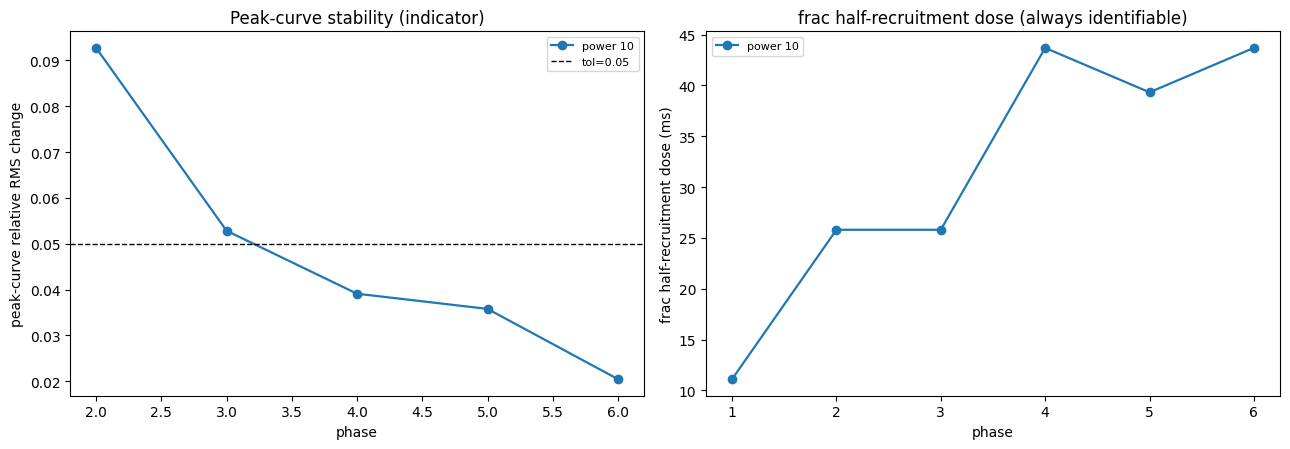

power 10: family='hill', last peak-RMS=0.020, converged-indicator=True


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for power, agent in agents.items():
    rep = agent.convergence_report()
    rms = rep["peak_rms_history"]
    hd = rep["frac_halfdose_history"]
    ph = np.arange(1, len(rms) + 1)
    axes[0].plot(ph, rms, "o-", lw=1.6, label=f"power {power}")
    axes[1].plot(np.arange(1, len(hd) + 1), hd, "o-", lw=1.6, label=f"power {power}")
_tol = list(agents.values())[0].stop_rms_tol if agents else 0.05
axes[0].axhline(_tol, color="k", ls="--", lw=1, label=f"tol={_tol}")
axes[0].set_xlabel("phase")
axes[0].set_ylabel("peak-curve relative RMS change")
axes[0].set_title("Peak-curve stability (indicator)")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("phase")
axes[1].set_ylabel("frac half-recruitment dose (ms)")
axes[1].set_title("frac half-recruitment dose (always identifiable)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

for power, agent in agents.items():
    rep = agent.convergence_report()
    last_rms = rep["peak_rms_history"][-1] if rep["peak_rms_history"] else float("nan")
    fam = rep["selected_family_history"][-1] if rep["selected_family_history"] else None
    print(
        f"power {power}: family={fam!r}, last peak-RMS={last_rms:.3f}, "
        f"converged-indicator={rep['is_converged']}"
    )

## Analysis 4 -- cross-power comparison + reciprocity check

Overlay the median-expression peak curves for all powers (left). Higher power
should lift and/or left-shift the curve. Right: the same curves replotted
against **total light = duration x power** -- if the curves collapse onto one,
reciprocity (Bunsen-Roscoe) holds and a light-budget axis is justified; if they
stay separate, power and duration are *not* interchangeable and blocking was the
right call.

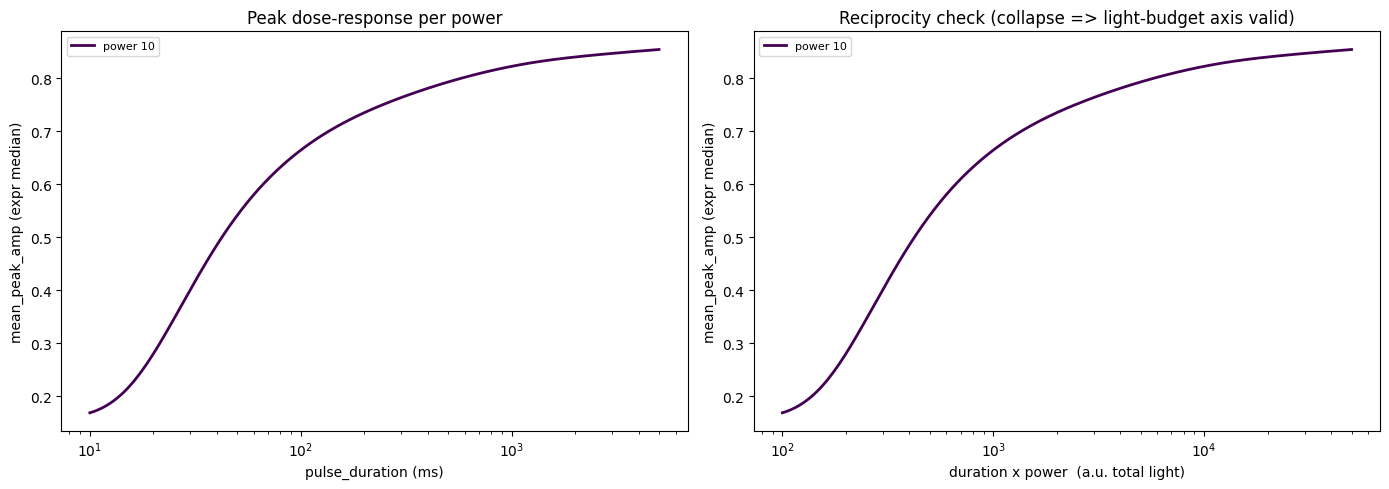

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cmap = plt.get_cmap("viridis")
powers_sorted = sorted(agents)
for i, power in enumerate(powers_sorted):
    agent = agents[power]
    if agent.df_results is None or agent.df_results.empty:
        continue
    doses, curves = predict_peak_stratified(agent, expr_percentiles=(50,))
    if curves is None:
        continue
    c = cmap(i / max(1, len(powers_sorted) - 1))
    axes[0].plot(doses, curves[50], color=c, lw=2, label=f"power {power}")
    axes[1].plot(doses * power, curves[50], color=c, lw=2, label=f"power {power}")
axes[0].set_xlabel("pulse_duration (ms)")
axes[0].set_ylabel("mean_peak_amp (expr median)")
axes[0].set_xscale("log")
axes[0].set_title("Peak dose-response per power")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("duration x power  (a.u. total light)")
axes[1].set_ylabel("mean_peak_amp (expr median)")
axes[1].set_title("Reciprocity check (collapse => light-budget axis valid)")
axes[1].set_xscale("log")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()